In [3]:
import pandas
import numpy

In [4]:
df = pandas.read_csv("WildScan_Data/Image_Data.csv", index_col = 0)

In [5]:
df = df.drop(columns = ["taxon_geoprivacy"])

In [6]:
df

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name
id,,,,,,,,,,,,,,,,,,,
11653,61ea3a20-37bd-4a29-af81-36f6c02a1336,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,needs_id,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,6,0,"Menlo Park, California, United States",NaN,gilled mushrooms,Agaricales,Common Gilled Mushrooms and Allies,Fungi,47167,Agaricales
22104,7014533a-afda-48e9-830b-2b11663f389e,"September 09, 2007 09:39",2024-11-12 14:57:24 UTC,needs_id,http://www.inaturalist.org/observations/22104,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,1,0,"Swakopmund, Namibia",NaN,Spiders,Araneae,Spiders,Arachnida,47118,Araneae
25000,18501b91-a648-422e-a8bf-f82eb91d8f38,2011-07-13,2025-08-24 16:19:56 UTC,needs_id,http://www.inaturalist.org/observations/25000,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,7,2,"bellevue, NE",NaN,shelf fungi,Polyporales,Shelf Fungi,Fungi,47380,Polyporales
25951,2e5c6826-a177-49e0-aae1-6bb3722a3953,2011-04-27,2025-10-18 20:59:42 UTC,needs_id,http://www.inaturalist.org/observations/25951,https://static.inaturalist.org/photos/46719/me...,NaN,Tree,Tronco de árvore envolto por fina teia (Tree s...,1,0,Pinhais - Paraná - Brasil,NaN,Butterflies and Moths,Lepidoptera,Butterflies and Moths,Insecta,47157,Lepidoptera
27704,24b054f8-4396-4db2-8048-f77663509dac,2009-05-15,2025-10-18 20:59:55 UTC,needs_id,http://www.inaturalist.org/observations/27704,https://static.inaturalist.org/photos/49548/me...,NaN,NaN,NaN,3,0,Costa Rica,NaN,Butterflies and Moths,Lepidoptera,Butterflies and Moths,Insecta,47157,Lepidoptera
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351418915,6ced88a0-d941-4bca-8470-90d14e3938af,2026/04/15 5:04 PM,2026-04-20 16:28:16 UTC,needs_id,https://www.inaturalist.org/observations/35141...,https://static.inaturalist.org/photos/64129111...,NaN,NaN,NaN,3,0,"Mount Surprise QLD 4871, Australia",NaN,Winged and Once-winged Insects,Pterygota,Winged and Once-winged Insects,Insecta,184884,NaN
351421067,5e658700-8be1-48ef-9808-5b50b5076a70,2026-04-20 13:42:20,2026-04-21 01:09:35 UTC,needs_id,https://www.inaturalist.org/observations/35142...,https://static.inaturalist.org/photos/64130472...,NaN,NaN,NaN,3,1,Dhyana Pura University,NaN,Butterflies and Moths,Lepidoptera,Butterflies and Moths,Insecta,47157,Lepidoptera
351433900,3e688007-4b66-4036-9377-b3a8fa025d3e,2026/01/21 14:08,2026-04-20 15:06:22 UTC,needs_id,https://www.inaturalist.org/observations/35143...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,2,1,"Labège, France",NaN,Placentaires,Placentalia,Placental Mammals,Mammalia,848320,NaN


In [7]:
from pathlib import Path

# Define the folder path
img_dir = Path('inat_images')

# Use rglob to find all image files (e.g., .jpg, .png)
image_paths = list(img_dir.rglob("*.jpg")) + list(img_dir.rglob("*.png"))

# Create a DataFrame
images = pandas.DataFrame({'filepath': image_paths})

In [8]:
images

,filepath
0,inat_images/109734991_Insecta_Psocodea.jpg
1,inat_images/117426245_Fungi_Agaricales.jpg
2,inat_images/158528642_Fungi_Agaricomycetes.jpg
3,inat_images/326483060_Insecta_Thysanoptera.jpg
4,inat_images/146829568_Fungi_Fungi.jpg
...,...
28872,inat_images/313859391_Insecta_Orthoptera.jpg
28873,inat_images/324179737_Insecta_Psocodea.jpg
28874,inat_images/63904654_Fungi_Pezizomycotina.jpg
28875,inat_images/.ipynb_checkpoints/22104_Arachnida...


In [9]:
images.loc[".ipynb"]

KeyError: '.ipynb'

In [10]:
images["filepath"] = images["filepath"].astype(str)

In [11]:
images.loc[0,"filepath"]

'inat_images/109734991_Insecta_Psocodea.jpg'

In [12]:
images["id"] = images["filepath"].apply(lambda x: x.split("/")[1].split("_")[0])

In [13]:
images

,filepath,id
0,inat_images/109734991_Insecta_Psocodea.jpg,109734991
1,inat_images/117426245_Fungi_Agaricales.jpg,117426245
2,inat_images/158528642_Fungi_Agaricomycetes.jpg,158528642
3,inat_images/326483060_Insecta_Thysanoptera.jpg,326483060
4,inat_images/146829568_Fungi_Fungi.jpg,146829568
...,...,...
28872,inat_images/313859391_Insecta_Orthoptera.jpg,313859391
28873,inat_images/324179737_Insecta_Psocodea.jpg,324179737
28874,inat_images/63904654_Fungi_Pezizomycotina.jpg,63904654
28875,inat_images/.ipynb_checkpoints/22104_Arachnida...,.ipynb


In [14]:
images = images[~images["filepath"].str.contains(".ipynb")]

In [15]:
images = images.set_index("id")

In [16]:
images

,filepath
id,
109734991,inat_images/109734991_Insecta_Psocodea.jpg
117426245,inat_images/117426245_Fungi_Agaricales.jpg
158528642,inat_images/158528642_Fungi_Agaricomycetes.jpg
326483060,inat_images/326483060_Insecta_Thysanoptera.jpg
146829568,inat_images/146829568_Fungi_Fungi.jpg
...,...
188239098,inat_images/188239098_Fungi_Agaricales.jpg
120837380,inat_images/120837380_Fungi_Agaricomycetes.jpg
313859391,inat_images/313859391_Insecta_Orthoptera.jpg


In [86]:
pandas.merge(df, images, left_index = True, right_index = True)

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,


In [17]:
images.index = images.index.astype("int64")

In [18]:
images.loc[".ipynb"]

KeyError: '.ipynb'

In [19]:
images

,filepath
id,
109734991,inat_images/109734991_Insecta_Psocodea.jpg
117426245,inat_images/117426245_Fungi_Agaricales.jpg
158528642,inat_images/158528642_Fungi_Agaricomycetes.jpg
326483060,inat_images/326483060_Insecta_Thysanoptera.jpg
146829568,inat_images/146829568_Fungi_Fungi.jpg
...,...
188239098,inat_images/188239098_Fungi_Agaricales.jpg
120837380,inat_images/120837380_Fungi_Agaricomycetes.jpg
313859391,inat_images/313859391_Insecta_Orthoptera.jpg


In [20]:
Main_dataframe = pandas.merge(df, images, left_index = True, right_index = True)

In [21]:
import os

image_folder = "inat_images"

filepaths = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(".jpg")]

df = pandas.DataFrame({"image_link":filepaths,"id": list(map(lambda x: x.split("/")[1].split("_")[0], filepaths))})

# Make clickable links
def make_clickable(path):
    return f'<a href="file://{path}" target="_blank">{path}</a>'

df_styled = df.style.format({"image_link": make_clickable})

In [170]:
pandas.merge(df_styled, Main_dataframe, left_on = "id", right_index = True, how = "inner")

TypeError: Can only merge Series or DataFrame objects, a <class 'pandas.io.formats.style.Styler'> was passed

In [186]:
Main_dataframe = Main_dataframe.drop(labels = [341814165])

In [195]:
Main_dataframe[Main_dataframe["num_identification_disagreements"] > 1]

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,
25000,18501b91-a648-422e-a8bf-f82eb91d8f38,2011-07-13,2025-08-24 16:19:56 UTC,needs_id,http://www.inaturalist.org/observations/25000,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,7,2,"bellevue, NE",NaN,shelf fungi,Polyporales,Shelf Fungi,Fungi,47380,Polyporales,inat_images/25000_Fungi_Polyporales.jpg
139489,06b63ffa-3b3f-46d0-93ab-e7dbf7a99e5a,2012-09-30,2026-04-16 01:25:36 UTC,needs_id,http://www.inaturalist.org/observations/139489,https://static.inaturalist.org/photos/193380/m...,NaN,NaN,NaN,6,2,"Madathara Kollam, India",NaN,Butterflies and Moths,Lepidoptera,Butterflies and Moths,Insecta,47157,Lepidoptera,inat_images/139489_Insecta_Lepidoptera.jpg
160407,bb5b2b32-eab8-4862-bf1a-4abb1032d4bb,Tue Dec 04 2012 14:17:57 GMT-0800 (PST),2025-03-30 11:05:46 UTC,needs_id,http://www.inaturalist.org/observations/160407,https://static.inaturalist.org/photos/217358/m...,NaN,NaN,NaN,5,2,"3625 Pepperwood Preserve Rd, Santa Rosa, Calif...",NaN,Fungi Including Lichens,Fungi,Fungi Including Lichens,Fungi,47170,NaN,inat_images/160407_Fungi_Fungi.jpg
3017338,dc0407ce-def0-47b4-ad7e-f7eaf593a088,Sat Apr 23 2016 16:16:50 GMT-0700 (PDT),2025-10-22 03:34:15 UTC,needs_id,http://www.inaturalist.org/observations/3017338,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,5,2,"Kings Canyon/sequoia, Sequoia National Park, S...",NaN,shelf fungi,Polyporales,Shelf Fungi,Fungi,47380,Polyporales,inat_images/3017338_Fungi_Polyporales.jpg
4367829,103026d1-c485-48a2-9432-e1ec729c9f7a,Fri Oct 14 2016 15:58:56 GMT-0500 (CDT),2022-08-31 18:58:34 UTC,needs_id,http://www.inaturalist.org/observations/4367829,https://static.inaturalist.org/photos/5234155/...,NaN,NaN,NaN,5,2,"4171–4173 County Road 2007, Glen Rose, TX, US",NaN,Scorpions,Scorpiones,Scorpions,Arachnida,48894,Scorpiones,inat_images/4367829_Arachnida_Scorpiones.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253519790,0e3f3067-a39a-49b4-8ec4-54c43bd30596,2024-10-23 14:59:31-03:00,2025-08-27 10:31:34 UTC,needs_id,https://www.inaturalist.org/observations/25351...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,6,2,"Santa Teresa, ES, BR",NaN,Baratas e térmitas,Blattodea,Cockroaches and Termites,Insecta,81769,Blattodea,inat_images/253519790_Insecta_Blattodea.jpg
259358377,1671d337-2299-46e1-9725-55454502aa57,2025-01-23 20:39:41+02:00,2025-06-24 11:20:23 UTC,needs_id,https://www.inaturalist.org/observations/25935...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,Parasite present on side of body.\n\nParasite ...,6,2,"Sugarloaf St. Lucia, St Lucia, KwaZulu-Natal, ZA",NaN,Coleoptera,Coleoptera,Beetles,Insecta,47208,Coleoptera,inat_images/259358377_Insecta_Coleoptera.jpg
274507397,a41c7bc5-7ca8-4b68-b18f-6afcaa863bb4,2025-04-27 12:32:17+10:00,2025-06-22 23:49:20 UTC,needs_id,https://www.inaturalist.org/observations/27450...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,4,2,"Wellington - Alberton, AU-VI, AU",NaN,Helotiales,Helotiales,NaN,Fungi,49073,Helotiales,inat_images/274507397_Fungi_Helotiales.jpg


In [202]:
for file_path in Main_dataframe[Main_dataframe["num_identification_disagreements"] > 1]["filepath"]:
    if os.path.exists(file_path):
        os.remove(file_path)
    else:
        print(f"File not found: {file_path}")

In [204]:
remaining_images = len([f for f in os.listdir("inat_images") if f.endswith(".jpg")])
print(f"Remaining images: {remaining_images}")

Remaining images: 28875


In [208]:
Main_dataframe[~Main_dataframe["num_identification_disagreements"] > 1]

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,


In [207]:
Main_dataframe

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,


In [275]:
Main_dataframe = Main_dataframe.reindex(columns = ['iconic_taxon_name', 'scientific_name', 'common_name', 'url','image_url', 'description', 'observed_on_string', 'updated_at', 'filepath', 'quality_grade', 'num_identification_agreements', 'num_identification_disagreements','place_guess', 'private_place_guess','species_guess', 'taxon_order_name', 'taxon_id', 'uuid', 'tag_list', 'sound_url'])

In [260]:
Main_dataframe[~Main_dataframe['species_guess'].str.isascii()]

AttributeError: 'StringMethods' object has no attribute 'isascii'

In [276]:
Main_dataframe

,iconic_taxon_name,scientific_name,common_name,url,image_url,description,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url
id,,,,,,,,,,,,,,,,,,,,
11653,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,inat_images/11653_Fungi_Agaricales.jpg,needs_id,6,0,"Menlo Park, California, United States",NaN,gilled mushrooms,Agaricales,47167,61ea3a20-37bd-4a29-af81-36f6c02a1336,NaN,NaN
22104,Arachnida,Araneae,Spiders,http://www.inaturalist.org/observations/22104,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"September 09, 2007 09:39",2024-11-12 14:57:24 UTC,inat_images/22104_Arachnida_Araneae.jpg,needs_id,1,0,"Swakopmund, Namibia",NaN,Spiders,Araneae,47118,7014533a-afda-48e9-830b-2b11663f389e,NaN,NaN
25951,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/25951,https://static.inaturalist.org/photos/46719/me...,Tronco de árvore envolto por fina teia (Tree s...,2011-04-27,2025-10-18 20:59:42 UTC,inat_images/25951_Insecta_Lepidoptera.jpg,needs_id,1,0,Pinhais - Paraná - Brasil,NaN,Butterflies and Moths,Lepidoptera,47157,2e5c6826-a177-49e0-aae1-6bb3722a3953,Tree,NaN
27704,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/27704,https://static.inaturalist.org/photos/49548/me...,NaN,2009-05-15,2025-10-18 20:59:55 UTC,inat_images/27704_Insecta_Lepidoptera.jpg,needs_id,3,0,Costa Rica,NaN,Butterflies and Moths,Lepidoptera,47157,24b054f8-4396-4db2-8048-f77663509dac,NaN,NaN
53140,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/53140,https://inaturalist-open-data.s3.amazonaws.com...,Dead wood.\r\n\r\nCataloochee area.,2010-08-04,2023-09-10 13:58:09 UTC,inat_images/53140_Fungi_Agaricales.jpg,needs_id,1,0,"Great Smoky Mountains National Park, North Car...",NaN,Common Gilled Mushrooms and Allies,Agaricales,47167,b0d19914-a045-4814-97b2-777accbda826,"orange, red",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351418915,Insecta,Pterygota,Winged and Once-winged Insects,https://www.inaturalist.org/observations/35141...,https://static.inaturalist.org/photos/64129111...,NaN,2026/04/15 5:04 PM,2026-04-20 16:28:16 UTC,inat_images/351418915_Insecta_Pterygota.jpg,needs_id,3,0,"Mount Surprise QLD 4871, Australia",NaN,Winged and Once-winged Insects,NaN,184884,6ced88a0-d941-4bca-8470-90d14e3938af,NaN,NaN
351421067,Insecta,Lepidoptera,Butterflies and Moths,https://www.inaturalist.org/observations/35142...,https://static.inaturalist.org/photos/64130472...,NaN,2026-04-20 13:42:20,2026-04-21 01:09:35 UTC,inat_images/351421067_Insecta_Lepidoptera.jpg,needs_id,3,1,Dhyana Pura University,NaN,Butterflies and Moths,Lepidoptera,47157,5e658700-8be1-48ef-9808-5b50b5076a70,NaN,NaN
351433900,Mammalia,Placentalia,Placental Mammals,https://www.inaturalist.org/observations/35143...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,2026/01/21 14:08,2026-04-20 15:06:22 UTC,inat_images/351433900_Mammalia_Placentalia.jpg,needs_id,2,1,"Labège, France",NaN,Placentaires,NaN,848320,3e688007-4b66-4036-9377-b3a8fa025d3e,NaN,NaN


Shape - (28875, 20)
Dtypes - num_identification_agreements : int 64, num_identification_disagreements : int 64, rest : str

In [344]:
Main_dataframe.describe()

,num_identification_agreements,num_identification_disagreements
count,28875.000000,28875.000000
mean,1.920312,0.121801
std,1.006208,0.327061
min,1.000000,0.000000
25%,1.000000,0.000000
50%,2.000000,0.000000
75%,2.000000,0.000000
max,13.000000,1.000000


In [345]:
import matplotlib.pyplot as plt

In [362]:
Main_barchart = Main_dataframe.groupby("common_name").count()

In [363]:
Main_barchart

,iconic_taxon_name,scientific_name,url,image_url,description,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url
common_name,,,,,,,,,,,,,,,,,,
"Alderflies, Dobsonflies, and Fishflies",3,3,3,3,0,3,3,3,3,3,3,3,3,3,3,3,0,0
Amphibians,34,34,34,34,10,34,34,34,34,34,34,34,34,0,34,34,1,0
Angel Insects,2,2,2,2,1,2,2,2,2,2,2,2,2,2,2,2,0,0
"Antlions, Lacewings, and Allies",88,88,88,88,31,88,88,88,88,88,88,87,87,88,88,88,2,0
"Ants, Bees, Wasps, and Sawflies",151,151,151,151,60,151,151,151,151,151,151,148,151,151,151,151,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"script lichens, whitewash lichens, and allies",4,4,4,4,1,4,4,4,4,4,4,4,4,4,4,4,1,0
"shield lichens, rim lichens, and allies",66,66,66,66,16,66,66,66,66,66,66,66,66,66,66,66,4,0
stinkhorns and allies,12,12,12,12,2,12,12,12,12,12,12,12,12,12,12,12,0,0


In [ ]:
Main_dataframe.

In [368]:
Main_barchart_taxon = Main_dataframe.groupby("iconic_taxon_name").count()

<Axes: ylabel='iconic_taxon_name'>

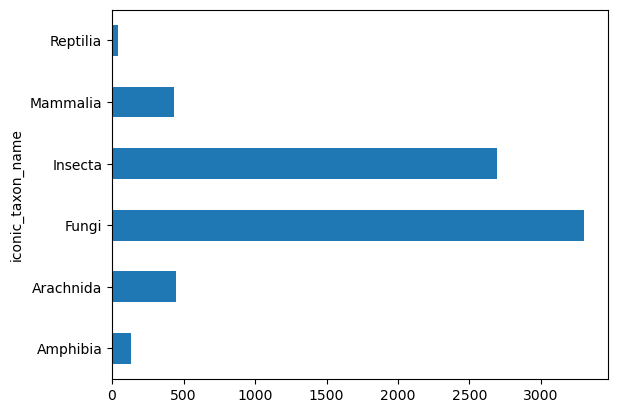

In [370]:
Main_barchart_taxon["description"].plot(kind = "barh")

In [28]:
Invertebrates = Main_dataframe[(Main_dataframe["iconic_taxon_name"] == "Insecta") | (Main_dataframe["iconic_taxon_name"] == "Arachnida")]

In [29]:
Vertebrates = Main_dataframe[(Main_dataframe["iconic_taxon_name"] == "Reptilia") | (Main_dataframe["iconic_taxon_name"] == "Mammilia") | (Main_dataframe["iconic_taxon_name"] == "Amphibia")] 

In [413]:
Vertebrates

,iconic_taxon_name,scientific_name,common_name,url,image_url,description,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url
id,,,,,,,,,,,,,,,,,,,
65871,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/65871,https://static.inaturalist.org/photos/100368/m...,Some tadpoles I saw swimming right near Epupa ...,2011-12-10,2025-06-17 10:46:02 UTC,inat_images/65871_Amphibia_Anura.jpg,needs_id,7,0,"Epupa falls, Namibia",Frogs and Toads,Anura,20979,0e25d153-9dc8-4b42-8d23-c0d2929d24e1,"tadpoles, namibia",NaN
498866,Amphibia,Anura,Frogs and Toads,http://conabio.inaturalist.org/observations/49...,https://static.inaturalist.org/photos/634633/m...,<NA>,2013-11-29 20:01:14,2026-02-24 05:14:23 UTC,inat_images/498866_Amphibia_Anura.jpg,needs_id,6,0,"Pedernales, Manabi, Ecuador",Frogs and Toads,Anura,20979,cf990774-d1b7-4709-a8b8-7c99dd0c2728,<NA>,NaN
694632,Amphibia,Gymnophiona,Caecilians,http://www.inaturalist.org/observations/694632,https://static.inaturalist.org/photos/871993/m...,<NA>,2014-05-22 8:52:49 PM CST,2025-08-18 10:04:28 UTC,inat_images/694632_Amphibia_Gymnophiona.jpg,needs_id,1,0,"San Carlos, CR-AL, CR",Caecilians,Gymnophiona,27880,a7e4b313-2ea6-4f08-856c-2fcac4c88d14,<NA>,NaN
1157672,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/1157672,https://inaturalist-open-data.s3.amazonaws.com...,very slimy looking grey/brown frog lying flat ...,2014-12-29 16:33,2025-12-16 20:42:34 UTC,inat_images/1157672_Amphibia_Anura.jpg,needs_id,3,0,Rio Cenepa,Frogs and Toads,Anura,20979,a6c7e387-7dce-4203-b28d-424ebcf64e9f,"frog, brown, grey, yellow line, red eyes, jung...",NaN
1161993,Amphibia,Anura,Frogs and Toads,http://naturewatch.org.nz/observations/1161993,https://inaturalist-open-data.s3.amazonaws.com...,tadpoles in an alpine tarn.,2015-01-01,2017-09-01 01:16:14 UTC,inat_images/1161993_Amphibia_Anura.jpg,needs_id,1,0,"Kelly Saddle, Otira",Anura,Anura,20979,af42d02e-ede0-4669-8bd7-45d935105625,<NA>,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346830825,Reptilia,Testudines,Turtles and Tortoises,https://www.inaturalist.org/observations/34683...,https://static.inaturalist.org/photos/63765434...,<NA>,Thu Apr 02 2026 14:24:07 GMT -0400 (EDT),2026-04-13 15:53:23 UTC,inat_images/346830825_Reptilia_Testudines.jpg,needs_id,2,1,"Maryland, US",Turtles and Tortoises,Testudines,39532,d139a77c-8648-47f3-8485-5ece21e2fafe,NaN,NaN
347883133,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34788...,https://inaturalist-open-data.s3.amazonaws.com...,<NA>,Mon Apr 06 2026 11:56:39 GMT -0700 (PDT),2026-04-07 22:06:50 UTC,inat_images/347883133_Amphibia_Anura.jpg,needs_id,2,0,"Butte County, US-CA, US",Frogs and Toads,Anura,20979,b2c28e61-498d-48ac-954a-8e1c14d10b8c,NaN,NaN
348170707,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34817...,https://static.inaturalist.org/photos/63997980...,<NA>,2026-04-06 08:16:09,2026-04-18 07:08:15 UTC,inat_images/348170707_Amphibia_Anura.jpg,needs_id,1,0,"Saltwater Creek Rd at Airport Drive, Maryborou...",Frogs and Toads,Anura,20979,7c2cc78c-1507-44a0-ac44-17d83625f517,NaN,NaN


In [22]:
Fungi = Main_dataframe[Main_dataframe["iconic_taxon_name"] == "Fungi"]

In [23]:
Fungi

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,
11653,61ea3a20-37bd-4a29-af81-36f6c02a1336,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,needs_id,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,6,0,"Menlo Park, California, United States",NaN,gilled mushrooms,Agaricales,Common Gilled Mushrooms and Allies,Fungi,47167,Agaricales,inat_images/11653_Fungi_Agaricales.jpg
53140,b0d19914-a045-4814-97b2-777accbda826,2010-08-04,2023-09-10 13:58:09 UTC,needs_id,http://www.inaturalist.org/observations/53140,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"orange, red",Dead wood.\r\n\r\nCataloochee area.,1,0,"Great Smoky Mountains National Park, North Car...",NaN,Common Gilled Mushrooms and Allies,Agaricales,Common Gilled Mushrooms and Allies,Fungi,47167,Agaricales,inat_images/53140_Fungi_Agaricales.jpg
86687,d1343a16-4a90-431c-8dd0-b99360434107,2009-12-14,2025-11-12 05:37:42 UTC,needs_id,http://www.inaturalist.org/observations/86687,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"orange, yellow, fungus","Undersides of bracket fungus, or some kind of ...",3,0,"Dorrigo National Park, New South Wales, Australia",NaN,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/86687_Fungi_Agaricomycetes.jpg
88059,3de57f16-1148-48ea-89e8-41e5c815f3e1,2012-06-04,2020-01-22 06:48:35 UTC,needs_id,http://www.inaturalist.org/observations/88059,https://static.inaturalist.org/photos/128535/m...,NaN,NaN,This tree was covered with a significant amoun...,1,0,"47.66125000000, -122.41150000000",NaN,Agaricomycetes,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/88059_Fungi_Agaricomycetes.jpg
89020,79bbe1c2-c6d0-4c1b-806e-588293479160,Sun Jun 03 2012 10:08:56 GMT-0400 (EDT),2019-01-24 14:56:05 UTC,needs_id,http://www.inaturalist.org/observations/89020,https://static.inaturalist.org/photos/129862/m...,NaN,NaN,NaN,2,0,"163 Stoney Hill Rd, Vineyard Haven, Massachuse...",NaN,Basidiomycete Fungi,Basidiomycota,Basidiomycete Fungi,Fungi,47169,NaN,inat_images/89020_Fungi_Basidiomycota.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350864309,1d381312-653e-4a16-93e6-8507cf432698,2026-04-16 14:00:33,2026-04-20 22:41:50 UTC,needs_id,https://www.inaturalist.org/observations/35086...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,Rust growing on Dicentra formosa,2,1,"Placer County, Tahoe National Forest, US-CA, US",NaN,rust fungi,Pucciniales,rust fungi,Fungi,69968,Pucciniales,inat_images/350864309_Fungi_Pucciniales.jpg
350969809,670970bf-37be-4d2e-babe-1ef62fd64ca0,2026-04-18 14:08:46,2026-04-19 17:13:20 UTC,needs_id,https://www.inaturalist.org/observations/35096...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"stacked, guild: entomopathogenic fungi",NaN,1,0,"Rose Glen Rd, Gladwyne, PA, US",NaN,Insect Destroyers,Entomophthorales,Insect Destroyers,Fungi,55115,Entomophthorales,inat_images/350969809_Fungi_Entomophthorales.jpg
351000967,20462abb-d1c8-4522-a440-ecc05573312e,Sat Apr 18 2026 11:12:04 GMT -0400 (EDT),2026-04-21 01:37:51 UTC,needs_id,https://www.inaturalist.org/observations/35100...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,?????,3,0,Windsor,NaN,Barometer Earthstars,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/351000967_Fungi_Agaricomycetes.jpg


In [378]:
Main_dataframe

,iconic_taxon_name,scientific_name,common_name,url,image_url,description,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url
id,,,,,,,,,,,,,,,,,,,
11653,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,<NA>,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,inat_images/11653_Fungi_Agaricales.jpg,needs_id,6,0,"Menlo Park, California, United States",gilled mushrooms,Agaricales,47167,61ea3a20-37bd-4a29-af81-36f6c02a1336,<NA>,NaN
22104,Arachnida,Araneae,Spiders,http://www.inaturalist.org/observations/22104,https://inaturalist-open-data.s3.amazonaws.com...,<NA>,"September 09, 2007 09:39",2024-11-12 14:57:24 UTC,inat_images/22104_Arachnida_Araneae.jpg,needs_id,1,0,"Swakopmund, Namibia",Spiders,Araneae,47118,7014533a-afda-48e9-830b-2b11663f389e,<NA>,NaN
25951,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/25951,https://static.inaturalist.org/photos/46719/me...,Tronco de árvore envolto por fina teia (Tree s...,2011-04-27,2025-10-18 20:59:42 UTC,inat_images/25951_Insecta_Lepidoptera.jpg,needs_id,1,0,Pinhais - Paraná - Brasil,Butterflies and Moths,Lepidoptera,47157,2e5c6826-a177-49e0-aae1-6bb3722a3953,Tree,NaN
27704,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/27704,https://static.inaturalist.org/photos/49548/me...,<NA>,2009-05-15,2025-10-18 20:59:55 UTC,inat_images/27704_Insecta_Lepidoptera.jpg,needs_id,3,0,Costa Rica,Butterflies and Moths,Lepidoptera,47157,24b054f8-4396-4db2-8048-f77663509dac,<NA>,NaN
53140,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/53140,https://inaturalist-open-data.s3.amazonaws.com...,Dead wood.\r\n\r\nCataloochee area.,2010-08-04,2023-09-10 13:58:09 UTC,inat_images/53140_Fungi_Agaricales.jpg,needs_id,1,0,"Great Smoky Mountains National Park, North Car...",Common Gilled Mushrooms and Allies,Agaricales,47167,b0d19914-a045-4814-97b2-777accbda826,"orange, red",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351418915,Insecta,Pterygota,Winged and Once-winged Insects,https://www.inaturalist.org/observations/35141...,https://static.inaturalist.org/photos/64129111...,NaN,2026/04/15 5:04 PM,2026-04-20 16:28:16 UTC,inat_images/351418915_Insecta_Pterygota.jpg,needs_id,3,0,"Mount Surprise QLD 4871, Australia",Winged and Once-winged Insects,<NA>,184884,6ced88a0-d941-4bca-8470-90d14e3938af,NaN,NaN
351421067,Insecta,Lepidoptera,Butterflies and Moths,https://www.inaturalist.org/observations/35142...,https://static.inaturalist.org/photos/64130472...,NaN,2026-04-20 13:42:20,2026-04-21 01:09:35 UTC,inat_images/351421067_Insecta_Lepidoptera.jpg,needs_id,3,1,Dhyana Pura University,Butterflies and Moths,Lepidoptera,47157,5e658700-8be1-48ef-9808-5b50b5076a70,NaN,NaN
351433900,Mammalia,Placentalia,Placental Mammals,https://www.inaturalist.org/observations/35143...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,2026/01/21 14:08,2026-04-20 15:06:22 UTC,inat_images/351433900_Mammalia_Placentalia.jpg,needs_id,2,1,"Labège, France",Placentaires,<NA>,848320,3e688007-4b66-4036-9377-b3a8fa025d3e,NaN,NaN


In [403]:
Invertebrates.columns

Index(['iconic_taxon_name', 'scientific_name', 'common_name', 'url',
       'image_url', 'description', 'observed_on_string', 'updated_at',
       'filepath', 'quality_grade', 'num_identification_agreements',
       'num_identification_disagreements', 'place_guess', 'species_guess',
       'taxon_order_name', 'taxon_id', 'uuid', 'tag_list', 'sound_url'],
      dtype='object')

In [424]:
Vertebrates = Vertebrates.reindex(columns = ['iconic_taxon_name', 'scientific_name', 'common_name', 'url',
       'image_url', 'observed_on_string', 'updated_at',
       'filepath', 'quality_grade', 'num_identification_agreements',
       'num_identification_disagreements', 'place_guess', 'species_guess',
       'taxon_order_name', 'taxon_id', 'uuid', 'tag_list', 'sound_url', 'description'])

In [425]:
Vertebrates

,iconic_taxon_name,scientific_name,common_name,url,image_url,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url,description
id,,,,,,,,,,,,,,,,,,,
65871,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/65871,https://static.inaturalist.org/photos/100368/m...,2011-12-10,2025-06-17 10:46:02 UTC,inat_images/65871_Amphibia_Anura.jpg,needs_id,7,0,"Epupa falls, Namibia",Frogs and Toads,Anura,20979,0e25d153-9dc8-4b42-8d23-c0d2929d24e1,"tadpoles, namibia",NaN,Some tadpoles I saw swimming right near Epupa ...
498866,Amphibia,Anura,Frogs and Toads,http://conabio.inaturalist.org/observations/49...,https://static.inaturalist.org/photos/634633/m...,2013-11-29 20:01:14,2026-02-24 05:14:23 UTC,inat_images/498866_Amphibia_Anura.jpg,needs_id,6,0,"Pedernales, Manabi, Ecuador",Frogs and Toads,Anura,20979,cf990774-d1b7-4709-a8b8-7c99dd0c2728,<NA>,NaN,<NA>
694632,Amphibia,Gymnophiona,Caecilians,http://www.inaturalist.org/observations/694632,https://static.inaturalist.org/photos/871993/m...,2014-05-22 8:52:49 PM CST,2025-08-18 10:04:28 UTC,inat_images/694632_Amphibia_Gymnophiona.jpg,needs_id,1,0,"San Carlos, CR-AL, CR",Caecilians,Gymnophiona,27880,a7e4b313-2ea6-4f08-856c-2fcac4c88d14,<NA>,NaN,<NA>
1157672,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/1157672,https://inaturalist-open-data.s3.amazonaws.com...,2014-12-29 16:33,2025-12-16 20:42:34 UTC,inat_images/1157672_Amphibia_Anura.jpg,needs_id,3,0,Rio Cenepa,Frogs and Toads,Anura,20979,a6c7e387-7dce-4203-b28d-424ebcf64e9f,"frog, brown, grey, yellow line, red eyes, jung...",NaN,very slimy looking grey/brown frog lying flat ...
1161993,Amphibia,Anura,Frogs and Toads,http://naturewatch.org.nz/observations/1161993,https://inaturalist-open-data.s3.amazonaws.com...,2015-01-01,2017-09-01 01:16:14 UTC,inat_images/1161993_Amphibia_Anura.jpg,needs_id,1,0,"Kelly Saddle, Otira",Anura,Anura,20979,af42d02e-ede0-4669-8bd7-45d935105625,<NA>,NaN,tadpoles in an alpine tarn.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346830825,Reptilia,Testudines,Turtles and Tortoises,https://www.inaturalist.org/observations/34683...,https://static.inaturalist.org/photos/63765434...,Thu Apr 02 2026 14:24:07 GMT -0400 (EDT),2026-04-13 15:53:23 UTC,inat_images/346830825_Reptilia_Testudines.jpg,needs_id,2,1,"Maryland, US",Turtles and Tortoises,Testudines,39532,d139a77c-8648-47f3-8485-5ece21e2fafe,NaN,NaN,<NA>
347883133,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34788...,https://inaturalist-open-data.s3.amazonaws.com...,Mon Apr 06 2026 11:56:39 GMT -0700 (PDT),2026-04-07 22:06:50 UTC,inat_images/347883133_Amphibia_Anura.jpg,needs_id,2,0,"Butte County, US-CA, US",Frogs and Toads,Anura,20979,b2c28e61-498d-48ac-954a-8e1c14d10b8c,NaN,NaN,<NA>
348170707,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34817...,https://static.inaturalist.org/photos/63997980...,2026-04-06 08:16:09,2026-04-18 07:08:15 UTC,inat_images/348170707_Amphibia_Anura.jpg,needs_id,1,0,"Saltwater Creek Rd at Airport Drive, Maryborou...",Frogs and Toads,Anura,20979,7c2cc78c-1507-44a0-ac44-17d83625f517,NaN,NaN,<NA>


In [429]:
Invertebrates_image_link = Invertebrates.copy()
Vertebrates_image_link = Vertebrates.copy()
Fungi_image_link = Fungi.copy()

In [437]:
import os
    
Fungi_image_link.insert(3, 'image_link', Fungi["filepath"])


# Make clickable links
def make_clickable(path):
    if pandas.isna(path):
        return "No Image"
    # use relative path from notebook location
    relative = os.path.relpath(path)
    return f'<a href="{relative}" target="_blank">{os.path.basename(path)}</a>'

# Render it again
from IPython.display import HTML
Fungi_image_link = HTML(Fungi_image_link.to_html(escape=False, formatters={'image_link': make_clickable}))

#df_styled = Invertebrates_image_link.style.format({"image_link": make_clickable})
#df_styled

In [439]:
Invertebrates

,iconic_taxon_name,scientific_name,common_name,url,image_url,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url,description
id,,,,,,,,,,,,,,,,,,,
22104,Arachnida,Araneae,Spiders,http://www.inaturalist.org/observations/22104,https://inaturalist-open-data.s3.amazonaws.com...,"September 09, 2007 09:39",2024-11-12 14:57:24 UTC,inat_images/22104_Arachnida_Araneae.jpg,needs_id,1,0,"Swakopmund, Namibia",Spiders,Araneae,47118,7014533a-afda-48e9-830b-2b11663f389e,<NA>,NaN,<NA>
25951,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/25951,https://static.inaturalist.org/photos/46719/me...,2011-04-27,2025-10-18 20:59:42 UTC,inat_images/25951_Insecta_Lepidoptera.jpg,needs_id,1,0,Pinhais - Paraná - Brasil,Butterflies and Moths,Lepidoptera,47157,2e5c6826-a177-49e0-aae1-6bb3722a3953,Tree,NaN,Tronco de árvore envolto por fina teia (Tree s...
27704,Insecta,Lepidoptera,Butterflies and Moths,http://www.inaturalist.org/observations/27704,https://static.inaturalist.org/photos/49548/me...,2009-05-15,2025-10-18 20:59:55 UTC,inat_images/27704_Insecta_Lepidoptera.jpg,needs_id,3,0,Costa Rica,Butterflies and Moths,Lepidoptera,47157,24b054f8-4396-4db2-8048-f77663509dac,<NA>,NaN,<NA>
126882,Insecta,Phasmida,Stick Insects,http://www.inaturalist.org/observations/126882,https://inaturalist-open-data.s3.amazonaws.com...,2008-09-06,2016-11-20 01:33:32 UTC,inat_images/126882_Insecta_Phasmida.jpg,needs_id,1,0,"Willcox, AZ",Stick Insects,Phasmida,47198,85b1b189-0e8d-4865-b525-645022a973b3,<NA>,NaN,<NA>
161753,Insecta,Phasmida,Stick Insects,http://www.inaturalist.org/observations/161753,https://static.inaturalist.org/photos/218423/m...,Wed Dec 12 2012 16:26:06 GMT-0600 (CST),2022-01-18 02:56:38 UTC,inat_images/161753_Insecta_Phasmida.jpg,needs_id,2,0,"19000–19736 Kuykendall Branch Rd, Salado, Texa...",Insectos palo y parientes,Phasmida,47198,37ac1409-c709-41a9-9aea-27d477c466b0,<NA>,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351269451,Insecta,Lepidoptera,Butterflies and Moths,https://www.inaturalist.org/observations/35126...,https://inaturalist-open-data.s3.amazonaws.com...,2026-04-19 11:29:16-04:00,2026-04-20 02:00:07 UTC,inat_images/351269451_Insecta_Lepidoptera.jpg,needs_id,2,1,"River Styx Rd, Wadsworth, OH, US",Butterflies and Moths,Lepidoptera,47157,cc00cee3-84e5-468a-9332-64126d532fe0,NaN,NaN,NaN
351290953,Insecta,Diptera,Flies,https://www.inaturalist.org/observations/35129...,https://inaturalist-open-data.s3.amazonaws.com...,2026-04-19 16:14:01,2026-04-19 22:44:49 UTC,inat_images/351290953_Insecta_Diptera.jpg,needs_id,1,0,"Puntarenas, CR",Flies,Diptera,47822,fe41a6ae-29e9-49ad-b690-84e822d6ec8b,NaN,NaN,NaN
351418915,Insecta,Pterygota,Winged and Once-winged Insects,https://www.inaturalist.org/observations/35141...,https://static.inaturalist.org/photos/64129111...,2026/04/15 5:04 PM,2026-04-20 16:28:16 UTC,inat_images/351418915_Insecta_Pterygota.jpg,needs_id,3,0,"Mount Surprise QLD 4871, Australia",Winged and Once-winged Insects,<NA>,184884,6ced88a0-d941-4bca-8470-90d14e3938af,NaN,NaN,NaN


In [440]:
Vertebrates

,iconic_taxon_name,scientific_name,common_name,url,image_url,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url,description
id,,,,,,,,,,,,,,,,,,,
65871,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/65871,https://static.inaturalist.org/photos/100368/m...,2011-12-10,2025-06-17 10:46:02 UTC,inat_images/65871_Amphibia_Anura.jpg,needs_id,7,0,"Epupa falls, Namibia",Frogs and Toads,Anura,20979,0e25d153-9dc8-4b42-8d23-c0d2929d24e1,"tadpoles, namibia",NaN,Some tadpoles I saw swimming right near Epupa ...
498866,Amphibia,Anura,Frogs and Toads,http://conabio.inaturalist.org/observations/49...,https://static.inaturalist.org/photos/634633/m...,2013-11-29 20:01:14,2026-02-24 05:14:23 UTC,inat_images/498866_Amphibia_Anura.jpg,needs_id,6,0,"Pedernales, Manabi, Ecuador",Frogs and Toads,Anura,20979,cf990774-d1b7-4709-a8b8-7c99dd0c2728,<NA>,NaN,<NA>
694632,Amphibia,Gymnophiona,Caecilians,http://www.inaturalist.org/observations/694632,https://static.inaturalist.org/photos/871993/m...,2014-05-22 8:52:49 PM CST,2025-08-18 10:04:28 UTC,inat_images/694632_Amphibia_Gymnophiona.jpg,needs_id,1,0,"San Carlos, CR-AL, CR",Caecilians,Gymnophiona,27880,a7e4b313-2ea6-4f08-856c-2fcac4c88d14,<NA>,NaN,<NA>
1157672,Amphibia,Anura,Frogs and Toads,http://www.inaturalist.org/observations/1157672,https://inaturalist-open-data.s3.amazonaws.com...,2014-12-29 16:33,2025-12-16 20:42:34 UTC,inat_images/1157672_Amphibia_Anura.jpg,needs_id,3,0,Rio Cenepa,Frogs and Toads,Anura,20979,a6c7e387-7dce-4203-b28d-424ebcf64e9f,"frog, brown, grey, yellow line, red eyes, jung...",NaN,very slimy looking grey/brown frog lying flat ...
1161993,Amphibia,Anura,Frogs and Toads,http://naturewatch.org.nz/observations/1161993,https://inaturalist-open-data.s3.amazonaws.com...,2015-01-01,2017-09-01 01:16:14 UTC,inat_images/1161993_Amphibia_Anura.jpg,needs_id,1,0,"Kelly Saddle, Otira",Anura,Anura,20979,af42d02e-ede0-4669-8bd7-45d935105625,<NA>,NaN,tadpoles in an alpine tarn.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346830825,Reptilia,Testudines,Turtles and Tortoises,https://www.inaturalist.org/observations/34683...,https://static.inaturalist.org/photos/63765434...,Thu Apr 02 2026 14:24:07 GMT -0400 (EDT),2026-04-13 15:53:23 UTC,inat_images/346830825_Reptilia_Testudines.jpg,needs_id,2,1,"Maryland, US",Turtles and Tortoises,Testudines,39532,d139a77c-8648-47f3-8485-5ece21e2fafe,NaN,NaN,<NA>
347883133,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34788...,https://inaturalist-open-data.s3.amazonaws.com...,Mon Apr 06 2026 11:56:39 GMT -0700 (PDT),2026-04-07 22:06:50 UTC,inat_images/347883133_Amphibia_Anura.jpg,needs_id,2,0,"Butte County, US-CA, US",Frogs and Toads,Anura,20979,b2c28e61-498d-48ac-954a-8e1c14d10b8c,NaN,NaN,<NA>
348170707,Amphibia,Anura,Frogs and Toads,https://www.inaturalist.org/observations/34817...,https://static.inaturalist.org/photos/63997980...,2026-04-06 08:16:09,2026-04-18 07:08:15 UTC,inat_images/348170707_Amphibia_Anura.jpg,needs_id,1,0,"Saltwater Creek Rd at Airport Drive, Maryborou...",Frogs and Toads,Anura,20979,7c2cc78c-1507-44a0-ac44-17d83625f517,NaN,NaN,<NA>


In [441]:
Fungi

,iconic_taxon_name,scientific_name,common_name,url,image_url,observed_on_string,updated_at,filepath,quality_grade,num_identification_agreements,num_identification_disagreements,place_guess,species_guess,taxon_order_name,taxon_id,uuid,tag_list,sound_url,description
id,,,,,,,,,,,,,,,,,,,
11653,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,inat_images/11653_Fungi_Agaricales.jpg,needs_id,6,0,"Menlo Park, California, United States",gilled mushrooms,Agaricales,47167,61ea3a20-37bd-4a29-af81-36f6c02a1336,<NA>,NaN,<NA>
53140,Fungi,Agaricales,Common Gilled Mushrooms and Allies,http://www.inaturalist.org/observations/53140,https://inaturalist-open-data.s3.amazonaws.com...,2010-08-04,2023-09-10 13:58:09 UTC,inat_images/53140_Fungi_Agaricales.jpg,needs_id,1,0,"Great Smoky Mountains National Park, North Car...",Common Gilled Mushrooms and Allies,Agaricales,47167,b0d19914-a045-4814-97b2-777accbda826,"orange, red",NaN,Dead wood.\r\n\r\nCataloochee area.
86687,Fungi,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",http://www.inaturalist.org/observations/86687,https://inaturalist-open-data.s3.amazonaws.com...,2009-12-14,2025-11-12 05:37:42 UTC,inat_images/86687_Fungi_Agaricomycetes.jpg,needs_id,3,0,"Dorrigo National Park, New South Wales, Australia","Mushrooms, Bracket Fungi, Puffballs, and Allies",<NA>,50814,d1343a16-4a90-431c-8dd0-b99360434107,"orange, yellow, fungus",NaN,"Undersides of bracket fungus, or some kind of ..."
88059,Fungi,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",http://www.inaturalist.org/observations/88059,https://static.inaturalist.org/photos/128535/m...,2012-06-04,2020-01-22 06:48:35 UTC,inat_images/88059_Fungi_Agaricomycetes.jpg,needs_id,1,0,"47.66125000000, -122.41150000000",Agaricomycetes,<NA>,50814,3de57f16-1148-48ea-89e8-41e5c815f3e1,<NA>,NaN,This tree was covered with a significant amoun...
89020,Fungi,Basidiomycota,Basidiomycete Fungi,http://www.inaturalist.org/observations/89020,https://static.inaturalist.org/photos/129862/m...,Sun Jun 03 2012 10:08:56 GMT-0400 (EDT),2019-01-24 14:56:05 UTC,inat_images/89020_Fungi_Basidiomycota.jpg,needs_id,2,0,"163 Stoney Hill Rd, Vineyard Haven, Massachuse...",Basidiomycete Fungi,<NA>,47169,79bbe1c2-c6d0-4c1b-806e-588293479160,<NA>,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350864309,Fungi,Pucciniales,rust fungi,https://www.inaturalist.org/observations/35086...,https://inaturalist-open-data.s3.amazonaws.com...,2026-04-16 14:00:33,2026-04-20 22:41:50 UTC,inat_images/350864309_Fungi_Pucciniales.jpg,needs_id,2,1,"Placer County, Tahoe National Forest, US-CA, US",rust fungi,Pucciniales,69968,1d381312-653e-4a16-93e6-8507cf432698,<NA>,NaN,Rust growing on Dicentra formosa
350969809,Fungi,Entomophthorales,Insect Destroyers,https://www.inaturalist.org/observations/35096...,https://inaturalist-open-data.s3.amazonaws.com...,2026-04-18 14:08:46,2026-04-19 17:13:20 UTC,inat_images/350969809_Fungi_Entomophthorales.jpg,needs_id,1,0,"Rose Glen Rd, Gladwyne, PA, US",Insect Destroyers,Entomophthorales,55115,670970bf-37be-4d2e-babe-1ef62fd64ca0,"stacked, guild: entomopathogenic fungi",NaN,<NA>
351000967,Fungi,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",https://www.inaturalist.org/observations/35100...,https://inaturalist-open-data.s3.amazonaws.com...,Sat Apr 18 2026 11:12:04 GMT -0400 (EDT),2026-04-21 01:37:51 UTC,inat_images/351000967_Fungi_Agaricomycetes.jpg,needs_id,3,0,Windsor,Barometer Earthstars,<NA>,50814,20462abb-d1c8-4522-a440-ecc05573312e,<NA>,NaN,?????


In [26]:
Fungi_image_dataset = Fungi[["iconic_taxon_name", "scientific_name", "common_name", "url", "image_url", "filepath", "num_identification_agreements","num_identification_disagreements", "taxon_id"]]

In [31]:
for i in Vertebrates["filepath"]:
    os.remove(i)

In [37]:
numpy.array(Fungi.groupby("scientific_name").count()["uuid"])

array([   1,    1, 3147, 3026,  223,  170,    1,    5,    1,  274,    2,
          2,   20,  336,  291,    1,    8,   10,    4,    1,    1,   10,
          1,    4,    1,    6,    6,    2,    1,   12,    3,   66,    2,
          6,    8,    2,    1,    3, 1880,    4,    2,    1,  108,  140,
         29,  276,    3,    4,    2,    5,    2,   66,  669,  124,    5,
          1,   51,    1,    2,    2,    1,    1,   37,    2,    8,    1,
          3,    2,    1,    1,    2,    4,   22,   56,   13,  137,   23,
        463,   12,    5,   13,  838,  109,   11,    2,    1,    5,   21,
          1,    1,    1,   63,    3,    1,    4,   40,    2,   34,    8,
          1,    7,    3,    2,   63])

In [33]:
print(Fungi["scientific_name"].unique())

['Agaricales' 'Agaricomycetes' 'Basidiomycota' 'Mucoromycota'
 'Pezizomycotina' 'Lecanoromycetes' 'Boletales' 'Polyporales' 'Ascomycota'
 'Helotiales' 'Caliciales' 'Fungi' 'Pucciniales' 'Xylariales'
 'Lecanorales' 'Lecanoromycetidae' 'Gomphales' 'Peltigerales'
 'Botryosphaeriales' 'Agaricomycotina' 'Mucorales' 'Sordariomycetes'
 'Leotiomycetes' 'Pezizales' 'Auriculariales' 'Agaricomycetidae'
 'Russulales' 'Entomophthorales' 'Hymenochaetales' 'Cantharellales'
 'Diaporthales' 'Thelephorales' 'Hypocreales' 'Corticiales' 'Arthoniales'
 'Tremellales' 'Phallales' 'Dacrymycetes' 'Lepidostromatales'
 'Saccharomycetes' 'Tremellomycetes' 'Geastrales' 'Pucciniomycetes'
 'Ostropomycetidae' 'Umbilicariales' 'Capnodiales' 'Rhytismatales'
 'Geoglossales' 'Pezizomycetes' 'Eurotiomycetidae' 'Phallomycetidae'
 'Sordariales' 'Orbiliomycetes' 'Pertusariales' 'Eurotiales'
 'Teloschistales' 'Atheliales' 'Laboulbeniales' 'Ustilaginomycetes'
 'Ostropales' 'Hysterangiales' 'Chytridiomycota' 'Lichinales' 'Lecid

In [41]:
numpy.array(Fungi.groupby("scientific_name").count().index)

array(['Acarosporales', 'Acarosporomycetidae', 'Agaricales',
       'Agaricomycetes', 'Agaricomycetidae', 'Agaricomycotina',
       'Amylocorticiales', 'Arthoniales', 'Arthoniomycetes', 'Ascomycota',
       'Asterinales', 'Atheliales', 'Auriculariales', 'Basidiomycota',
       'Boletales', 'Botryosphaeriales', 'Caliciales', 'Cantharellales',
       'Capnodiales', 'Chaetothyriales', 'Chytridiales',
       'Chytridiomycota', 'Coronophorales', 'Corticiales',
       'Coryneliomycetidae', 'Dacrymycetales', 'Dacrymycetes',
       'Diaporthales', 'Diaporthomycetidae', 'Dothideomycetes',
       'Endogonales', 'Entomophthorales', 'Entomophthoromycetes',
       'Entomophthoromycota', 'Eurotiales', 'Eurotiomycetes',
       'Eurotiomycetidae', 'Exobasidiales', 'Fungi', 'Geastrales',
       'Geoglossales', 'Glomeromycota', 'Gomphales', 'Helotiales',
       'Hymenochaetales', 'Hypocreales', 'Hypocreomycetidae',
       'Hysterangiales', 'Hysteriales', 'Laboulbeniales',
       'Laboulbeniomycetes', 'L

In [43]:
Fungi.groupby("scientific_name").count()

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
scientific_name,,,,,,,,,,,,,,,,,,,
Acarosporales,1,1,1,1,1,1,0,0,0,1,1,1,0,1,1,1,1,1,1
Acarosporomycetidae,1,1,1,1,1,1,0,1,1,1,1,1,0,1,1,1,1,0,1
Agaricales,3147,3147,3147,3147,3147,3147,0,81,581,3147,3147,3136,0,3145,3147,3147,3147,3147,3147
Agaricomycetes,3026,3026,3026,3026,3026,3026,0,64,553,3026,3026,3013,0,3025,3026,3026,3026,0,3026
Agaricomycetidae,223,223,223,223,223,223,0,3,28,223,223,223,0,223,0,223,223,0,223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Umbilicariales,1,1,1,1,1,1,0,0,1,1,1,1,0,1,1,1,1,1,1
Ustilaginomycetes,7,7,7,7,7,7,0,0,4,7,7,7,0,7,7,7,7,0,7
Ustilaginomycotina,3,3,3,3,3,3,0,0,1,3,3,3,0,3,0,3,3,0,3


In [45]:
Fungi.to_csv("fungi_dataframe.csv", index=False)

In [56]:
import os
import time
import csv
import re
from pathlib import Path
from urllib.parse import urlparse
 
import pandas as pd
import requests
from tqdm import tqdm
 
# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
 
EXISTING_DATAFRAME = "fungi_dataframe.csv"
EXISTING_IMAGES_DIR = Path("inat_images")
OUTPUT_DATAFRAME = "fungi_dataframe_extended.csv"
 
# Folders to process — folder name is the group label for filename consistency.
# (The actual scientific_name comes from each CSV row, not the folder.)
NEW_DATA_FOLDERS = [
    "Fungus_Bolete.csv",
    "Fungus_jellies.csv",
    "Fungus_puffballs.csv",
    "Fungus_clubs&Corals.csv"
]
 
ICONIC_TAXON_NAME = "Fungi"   # matches your existing filename pattern
 
# Be nice to iNaturalist's servers
DOWNLOAD_DELAY_SEC = 0.3      # pause between downloads (seconds)
REQUEST_TIMEOUT = 30          # seconds per download
MAX_RETRIES = 2
 
# ----------------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------------
 
def get_existing_ids(images_dir):
    """Return set of observation IDs that already have a file in inat_images/."""
    if not images_dir.exists():
        return set()
    ids = set()
    for f in images_dir.iterdir():
        if not f.is_file():
            continue
        # filename pattern: <id>_<iconic>_<sci>.jpg → split on first underscore
        m = re.match(r"^(\d+)_", f.name)
        if m:
            ids.add(int(m.group(1)))
    return ids
 
 
def sanitize_for_filename(s):
    """Make a string safe for use in a filename."""
    if not isinstance(s, str):
        return "unknown"
    # Remove anything that's not letters, digits, hyphens, or underscores.
    cleaned = re.sub(r"[^A-Za-z0-9_-]", "_", s.strip())
    cleaned = re.sub(r"_+", "_", cleaned)   # collapse repeated underscores
    cleaned = cleaned.strip("_")
    return cleaned or "unknown"
 
 
def download_one(url, dest_path, session):
    """Download URL to dest_path, retrying on transient failures."""
    for attempt in range(MAX_RETRIES + 1):
        try:
            r = session.get(url, timeout=REQUEST_TIMEOUT, stream=True)
            r.raise_for_status()
            with open(dest_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
            # Sanity check: did we actually write something?
            if dest_path.stat().st_size < 1000:    # < 1KB is almost certainly an error
                dest_path.unlink()
                raise ValueError(f"Downloaded file too small ({dest_path.stat().st_size} bytes)")
            return True
        except Exception as e:
            if attempt < MAX_RETRIES:
                time.sleep(1 + attempt)   # backoff
                continue
            # Last attempt failed — clean up if a partial file was written
            if dest_path.exists():
                dest_path.unlink()
            return False, str(e)
    return False, "unknown error"
 
 
def find_column(df, candidates):
    """Find which column name in `candidates` exists in df (case-insensitive)."""
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]
    return None
 
 
# ----------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------
 
def main():
    # ------- 1. Check that the existing assets are where we expect them -------
    if not Path(EXISTING_DATAFRAME).exists():
        print(f"ERROR: {EXISTING_DATAFRAME} not found. Export your Fungi dataframe first:")
        print('    Fungi.to_csv("fungi_dataframe.csv", index=False)')
        return
 
    EXISTING_IMAGES_DIR.mkdir(exist_ok=True)
 
    # ------- 2. Load the existing dataframe, remember its columns ----------
    print(f"Loading existing dataframe: {EXISTING_DATAFRAME}")
    existing_df = pd.read_csv(EXISTING_DATAFRAME)
    print(f"  {len(existing_df)} existing rows")
    print(f"  columns: {list(existing_df.columns)}")
 
    # Find existing observation IDs (from disk AND from dataframe)
    ids_on_disk = get_existing_ids(EXISTING_IMAGES_DIR)
    print(f"\n{len(ids_on_disk)} observation IDs already in {EXISTING_IMAGES_DIR}/")
 
    ids_in_df = set()
    if "id" in existing_df.columns:
        ids_in_df = set(existing_df["id"].dropna().astype(int))
    elif "filepath" in existing_df.columns:
        # Recover IDs from filepaths
        for fp in existing_df["filepath"].dropna():
            m = re.search(r"(\d+)_", os.path.basename(fp))
            if m:
                ids_in_df.add(int(m.group(1)))
    print(f"{len(ids_in_df)} observation IDs already in dataframe")
 
    # Combined set — skip any of these
    already_have = ids_on_disk | ids_in_df
    print(f"Total unique IDs to skip during download: {len(already_have)}\n")
 
    # ------- 3. Process each new-data folder -------------------------------
    session = requests.Session()
    session.headers.update({
        "User-Agent": "FungiClassifier/1.0 (educational project)",
    })
 
    new_rows = []
    total_downloaded = 0
    total_skipped = 0
    total_failed = 0
 
    for folder in NEW_DATA_FOLDERS:
        csv_path = Path(folder) / "observations.csv"
        if not csv_path.exists():
            print(f"Skipping {folder}/ — observations.csv not found")
            continue
 
        print(f"\n{'='*60}")
        print(f"Processing {csv_path}")
        print('='*60)
 
        df = pd.read_csv(csv_path)
        print(f"  {len(df)} rows in CSV")
        print(f"  columns: {list(df.columns)}")
 
        # Find the columns we need (be flexible about exact naming)
        id_col = find_column(df, ["id", "observation_id"])
        url_col = find_column(df, ["image_url", "photo_url", "url"])
        sci_col = find_column(df, ["scientific_name", "taxon_name"])
 
        if not id_col or not url_col or not sci_col:
            print(f"  ERROR: missing required columns. Found: id={id_col}, url={url_col}, sci_name={sci_col}")
            continue
 
        # Drop rows missing essential data
        df = df.dropna(subset=[id_col, url_col, sci_col])
 
        # ----- Within-folder dedup: same id might appear multiple times -----
        before = len(df)
        df = df.drop_duplicates(subset=[id_col], keep="first")
        if len(df) < before:
            print(f"  Removed {before - len(df)} duplicate rows within this CSV")
 
        # ----- Skip rows whose ID we already have -----
        df["_id_int"] = df[id_col].astype(int)
        new_in_folder = df[~df["_id_int"].isin(already_have)]
        skipped_in_folder = len(df) - len(new_in_folder)
        total_skipped += skipped_in_folder
        print(f"  {skipped_in_folder} already in dataset, {len(new_in_folder)} new to download")
 
        # ----- Download loop -----
        downloaded_in_folder = 0
        failed_in_folder = 0
 
        for _, row in tqdm(new_in_folder.iterrows(), total=len(new_in_folder),
                           desc=f"  {folder}"):
            obs_id = int(row[id_col])
            url = row[url_col]
            sci_name = row[sci_col]
            sci_clean = sanitize_for_filename(sci_name)
 
            filename = f"{obs_id}_{ICONIC_TAXON_NAME}_{sci_clean}.jpg"
            dest_path = EXISTING_IMAGES_DIR / filename
 
            if dest_path.exists():
                # Race condition / very rare, but be safe
                already_have.add(obs_id)
                continue
 
            result = download_one(url, dest_path, session)
            ok = result is True
            if ok:
                downloaded_in_folder += 1
                already_have.add(obs_id)
                # Build a row matching the existing dataframe's columns
                new_row = {col: None for col in existing_df.columns}
                if "iconic_taxon_name" in new_row:
                    new_row["iconic_taxon_name"] = ICONIC_TAXON_NAME
                if "scientific_name" in new_row:
                    new_row["scientific_name"] = sci_name
                if "filepath" in new_row:
                    new_row["filepath"] = str(dest_path)
                if "image_url" in new_row:
                    new_row["image_url"] = url
                if "id" in new_row:
                    new_row["id"] = obs_id
                # Fill any other columns the original df has, when we can
                for col in existing_df.columns:
                    if col in row.index and col not in new_row:
                        new_row[col] = row[col]
                new_rows.append(new_row)
            else:
                failed_in_folder += 1
                _, err = result
                # Don't spam — only print the first few failures per folder
                if failed_in_folder <= 3:
                    tqdm.write(f"    Failed to download id={obs_id}: {err}")
 
            time.sleep(DOWNLOAD_DELAY_SEC)
 
        total_downloaded += downloaded_in_folder
        total_failed += failed_in_folder
        print(f"  Folder summary: downloaded {downloaded_in_folder}, "
              f"failed {failed_in_folder}, skipped {skipped_in_folder}")
 
    # ------- 4. Merge into dataframe and save ----------------------------
    print(f"\n{'='*60}")
    print("Final summary")
    print('='*60)
    print(f"  Downloaded: {total_downloaded}")
    print(f"  Skipped (already had):  {total_skipped}")
    print(f"  Failed:     {total_failed}")
 
    if new_rows:
        new_df = pd.DataFrame(new_rows, columns=existing_df.columns)
        merged = pd.concat([existing_df, new_df], ignore_index=True)
        # Final dedup pass on filepath (just in case)
        if "filepath" in merged.columns:
            merged = merged.drop_duplicates(subset=["filepath"], keep="first")
        merged.to_csv(OUTPUT_DATAFRAME, index=False)
        print(f"\nSaved merged dataframe: {OUTPUT_DATAFRAME} ({len(merged)} rows)")
 
        # Per-class counts (using scientific_name)
        if "scientific_name" in merged.columns:
            print("\nUpdated counts for the new groups:")
            for sn in sorted(set(r["scientific_name"] for r in new_rows if r.get("scientific_name"))):
                count = (merged["scientific_name"] == sn).sum()
                print(f"  {sn:30s} {count}")
    else:
        print("\nNo new rows added — original dataframe unchanged.")
        print(f"(Did not write {OUTPUT_DATAFRAME})")
 
    print("\nNext step: update DATAFRAME_PATH in train_fungi.py to point to")
    print(f"  '{OUTPUT_DATAFRAME}' (or rename it to fungi_dataframe.csv).")
 
 
if __name__ == "__main__":
    main()

Loading existing dataframe: fungi_dataframe.csv
  13064 existing rows
  columns: ['uuid', 'observed_on_string', 'updated_at', 'quality_grade', 'url', 'image_url', 'sound_url', 'tag_list', 'description', 'num_identification_agreements', 'num_identification_disagreements', 'place_guess', 'private_place_guess', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id', 'taxon_order_name', 'filepath']

17097 observation IDs already in inat_images/
13064 observation IDs already in dataframe
Total unique IDs to skip during download: 17097


Processing Fungus_Bolete.csv/observations.csv
  689 rows in CSV
  columns: ['id', 'uuid', 'user_name', 'url', 'image_url', 'num_identification_agreements', 'num_identification_disagreements', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id', 'taxon_kingdom_name', 'taxon_phylum_name', 'taxon_species_name']
  689 already in dataset, 0 new to download


  Fungus_Bolete.csv: 0it [00:00, ?it/s]


  Folder summary: downloaded 0, failed 0, skipped 689

Processing Fungus_jellies.csv/observations.csv
  927 rows in CSV
  columns: ['id', 'uuid', 'user_name', 'url', 'image_url', 'num_identification_agreements', 'num_identification_disagreements', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id', 'taxon_kingdom_name', 'taxon_phylum_name', 'taxon_species_name']
  927 already in dataset, 0 new to download


  Fungus_jellies.csv: 0it [00:00, ?it/s]


  Folder summary: downloaded 0, failed 0, skipped 927

Processing Fungus_puffballs.csv/observations.csv
  403 rows in CSV
  columns: ['id', 'uuid', 'user_name', 'url', 'image_url', 'num_identification_agreements', 'num_identification_disagreements', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id', 'taxon_kingdom_name', 'taxon_phylum_name', 'taxon_species_name']
  403 already in dataset, 0 new to download


  Fungus_puffballs.csv: 0it [00:00, ?it/s]


  Folder summary: downloaded 0, failed 0, skipped 403

Processing Fungus_clubs&Corals.csv/observations.csv
  853 rows in CSV
  columns: ['id', 'uuid', 'user_name', 'url', 'image_url', 'num_identification_agreements', 'num_identification_disagreements', 'species_guess', 'scientific_name', 'common_name', 'iconic_taxon_name', 'taxon_id', 'taxon_kingdom_name', 'taxon_phylum_name', 'taxon_species_name']
  853 already in dataset, 0 new to download


  Fungus_clubs&Corals.csv: 0it [00:00, ?it/s]

  Folder summary: downloaded 0, failed 0, skipped 853

Final summary
  Downloaded: 0
  Skipped (already had):  2872
  Failed:     0

No new rows added — original dataframe unchanged.
(Did not write fungi_dataframe_extended.csv)

Next step: update DATAFRAME_PATH in train_fungi.py to point to
  'fungi_dataframe_extended.csv' (or rename it to fungi_dataframe.csv).


In [49]:
Fungi

,uuid,observed_on_string,updated_at,quality_grade,url,image_url,sound_url,tag_list,description,num_identification_agreements,num_identification_disagreements,place_guess,private_place_guess,species_guess,scientific_name,common_name,iconic_taxon_name,taxon_id,taxon_order_name,filepath
id,,,,,,,,,,,,,,,,,,,,
11653,61ea3a20-37bd-4a29-af81-36f6c02a1336,"January 15, 2011 16:39",2023-09-03 15:31:30 UTC,needs_id,http://www.inaturalist.org/observations/11653,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,NaN,6,0,"Menlo Park, California, United States",NaN,gilled mushrooms,Agaricales,Common Gilled Mushrooms and Allies,Fungi,47167,Agaricales,inat_images/11653_Fungi_Agaricales.jpg
53140,b0d19914-a045-4814-97b2-777accbda826,2010-08-04,2023-09-10 13:58:09 UTC,needs_id,http://www.inaturalist.org/observations/53140,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"orange, red",Dead wood.\r\n\r\nCataloochee area.,1,0,"Great Smoky Mountains National Park, North Car...",NaN,Common Gilled Mushrooms and Allies,Agaricales,Common Gilled Mushrooms and Allies,Fungi,47167,Agaricales,inat_images/53140_Fungi_Agaricales.jpg
86687,d1343a16-4a90-431c-8dd0-b99360434107,2009-12-14,2025-11-12 05:37:42 UTC,needs_id,http://www.inaturalist.org/observations/86687,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"orange, yellow, fungus","Undersides of bracket fungus, or some kind of ...",3,0,"Dorrigo National Park, New South Wales, Australia",NaN,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/86687_Fungi_Agaricomycetes.jpg
88059,3de57f16-1148-48ea-89e8-41e5c815f3e1,2012-06-04,2020-01-22 06:48:35 UTC,needs_id,http://www.inaturalist.org/observations/88059,https://static.inaturalist.org/photos/128535/m...,NaN,NaN,This tree was covered with a significant amoun...,1,0,"47.66125000000, -122.41150000000",NaN,Agaricomycetes,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/88059_Fungi_Agaricomycetes.jpg
89020,79bbe1c2-c6d0-4c1b-806e-588293479160,Sun Jun 03 2012 10:08:56 GMT-0400 (EDT),2019-01-24 14:56:05 UTC,needs_id,http://www.inaturalist.org/observations/89020,https://static.inaturalist.org/photos/129862/m...,NaN,NaN,NaN,2,0,"163 Stoney Hill Rd, Vineyard Haven, Massachuse...",NaN,Basidiomycete Fungi,Basidiomycota,Basidiomycete Fungi,Fungi,47169,NaN,inat_images/89020_Fungi_Basidiomycota.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350864309,1d381312-653e-4a16-93e6-8507cf432698,2026-04-16 14:00:33,2026-04-20 22:41:50 UTC,needs_id,https://www.inaturalist.org/observations/35086...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,Rust growing on Dicentra formosa,2,1,"Placer County, Tahoe National Forest, US-CA, US",NaN,rust fungi,Pucciniales,rust fungi,Fungi,69968,Pucciniales,inat_images/350864309_Fungi_Pucciniales.jpg
350969809,670970bf-37be-4d2e-babe-1ef62fd64ca0,2026-04-18 14:08:46,2026-04-19 17:13:20 UTC,needs_id,https://www.inaturalist.org/observations/35096...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,"stacked, guild: entomopathogenic fungi",NaN,1,0,"Rose Glen Rd, Gladwyne, PA, US",NaN,Insect Destroyers,Entomophthorales,Insect Destroyers,Fungi,55115,Entomophthorales,inat_images/350969809_Fungi_Entomophthorales.jpg
351000967,20462abb-d1c8-4522-a440-ecc05573312e,Sat Apr 18 2026 11:12:04 GMT -0400 (EDT),2026-04-21 01:37:51 UTC,needs_id,https://www.inaturalist.org/observations/35100...,https://inaturalist-open-data.s3.amazonaws.com...,NaN,NaN,?????,3,0,Windsor,NaN,Barometer Earthstars,Agaricomycetes,"Mushrooms, Bracket Fungi, Puffballs, and Allies",Fungi,50814,NaN,inat_images/351000967_Fungi_Agaricomycetes.jpg


In [51]:
import pandas as pd
import os

# Load the merged dataframe
merged = pd.read_csv("fungi_dataframe_extended.csv")
print(f"Total rows: {len(merged)}")

# Verify the new groups got their images
print("\nCounts for the relevant scientific_names:")
relevant = [
    "Boletales",         # bolete
    "Gomphales",         # coral
    "Cantharellales",    # coral
    "Geoglossales",      # coral
    "Phallales",         # puffballs
    "Tremellales",       # jellies
    # add any from your additional 2 folders here
]
for sn in relevant:
    if sn in merged["scientific_name"].values:
        count = (merged["scientific_name"] == sn).sum()
        print(f"  {sn:25s} {count}")

# Check all filepaths exist
missing = (~merged["filepath"].apply(os.path.exists)).sum()
print(f"\n{missing} of {len(merged)} image files missing on disk")

Total rows: 14394

Counts for the relevant scientific_names:
  Boletales                 291
  Gomphales                 108
  Cantharellales            10
  Geoglossales              2
  Phallales                 12
  Tremellales               34

0 of 14394 image files missing on disk


In [52]:
import pandas as pd

original = pd.read_csv("fungi_dataframe.csv")
merged   = pd.read_csv("fungi_dataframe_extended.csv")

print(f"Original rows: {len(original)}")
print(f"'Merged' rows: {len(merged)}")
print(f"Difference:    {len(merged) - len(original)}")

Original rows: 13064
'Merged' rows: 14394
Difference:    1330


In [53]:
GROUP_MAP = {
    # Order-level (your original data)
    "Boletales": "bolete_mushrooms",
    
    # Species/genus level (new downloads)
    "Boletus edulis": "bolete_mushrooms",
    "Boletus": "bolete_mushrooms",
    "Suillus": "bolete_mushrooms",
    "Leccinum": "bolete_mushrooms",
    # ... etc
}

In [54]:
import pandas as pd

original = pd.read_csv("fungi_dataframe.csv")
merged   = pd.read_csv("fungi_dataframe_extended.csv")

# Find the new rows (those not in original)
new_rows = merged[~merged["filepath"].isin(original["filepath"])]
print(f"New rows: {len(new_rows)}")

# What scientific_names do these new rows have?
print("\nScientific names in the new downloads:")
print(new_rows["scientific_name"].value_counts().head(30))

New rows: 1330

Scientific names in the new downloads:
scientific_name
Naematelia aurantia         779
Lycoperdon perlatum         206
Tremella mesenterica         91
Calvatia booniana            61
Phaeotremella foliacea       48
Bovista plumbea              30
Lycoperdon umbrinum          19
Lycoperdon pratense          16
Apioperdon pyriforme         13
Calvatia pachyderma          11
Calbovista subsculpta        11
Lycoperdon subumbrinum        9
Calvatia sculpta              7
Phaeotremella frondosa        7
Calvatia cyathiformis         6
Lycoperdon marginatum         5
Handkea fumosa                2
Naematelia encephala          1
Phaeotremella fimbriata       1
Calvatia gigantea             1
Mycenastrum corium            1
Calvatia rubroflava           1
Lycoperdon molle              1
Lycoperdon excipuliforme      1
Lycoperdon echinatum          1
Calvatia fragilis             1
Name: count, dtype: int64


In [57]:
import pandas as pd
import os
import re

# Load existing dataframe IDs
existing = pd.read_csv("fungi_dataframe.csv")
existing_ids = set()
for fp in existing["filepath"].dropna():
    m = re.search(r"(\d+)_", os.path.basename(fp))
    if m:
        existing_ids.add(int(m.group(1)))

# Load IDs from disk (inat_images/)
disk_ids = set()
for f in os.listdir("inat_images"):
    m = re.match(r"^(\d+)_", f)
    if m:
        disk_ids.add(int(m.group(1)))

# Check each new CSV
for csv_name in ["Fungus_puffballs.csv", "Fungus_clubs&Corals.csv"]:
    csv_path = os.path.join(csv_name, "observations.csv")
    if not os.path.exists(csv_path):
        csv_path = csv_name   # try without the folder
    if not os.path.exists(csv_path):
        print(f"{csv_name}: NOT FOUND")
        continue
    
    df = pd.read_csv(csv_path)
    new_ids = set(df["id"].astype(int))
    
    overlap_with_df = new_ids & existing_ids
    overlap_with_disk = new_ids & disk_ids
    truly_new = new_ids - existing_ids - disk_ids
    
    print(f"\n{csv_name}:")
    print(f"  {len(new_ids)} IDs in CSV")
    print(f"  {len(overlap_with_df)} already in existing dataframe")
    print(f"  {len(overlap_with_disk)} already in inat_images/")
    print(f"  {len(truly_new)} truly new")


Fungus_puffballs.csv:
  403 IDs in CSV
  0 already in existing dataframe
  403 already in inat_images/
  0 truly new

Fungus_clubs&Corals.csv:
  853 IDs in CSV
  0 already in existing dataframe
  853 already in inat_images/
  0 truly new


In [58]:
import pandas as pd

merged = pd.read_csv("fungi_dataframe_extended.csv")
print(f"Total rows in extended: {len(merged)}")

# Check that all the new species names are there
new_species_to_check = [
    "Lycoperdon perlatum",
    "Naematelia aurantia",
    "Calvatia booniana",
    "Cantharellus",        # any coral-related?
    "Ramaria",
    "Clavulina",
]
print("\nLooking for new species in extended dataframe:")
for sn in new_species_to_check:
    # Use 'contains' to catch both exact match and "Cantharellus formosus" etc.
    count = merged["scientific_name"].fillna("").str.contains(sn, regex=False).sum()
    print(f"  '{sn}': {count} matches")

# Also: how many rows have a *species-level* name (two words, capitalized)?
import re
species_pattern = merged["scientific_name"].fillna("").str.match(r"^[A-Z][a-z]+ [a-z]+")
print(f"\nRows with species-level names (e.g., 'Genus species'): {species_pattern.sum()}")
print("Sample of these:")
print(merged[species_pattern]["scientific_name"].value_counts().head(15))

Total rows in extended: 14394

Looking for new species in extended dataframe:
  'Lycoperdon perlatum': 206 matches
  'Naematelia aurantia': 779 matches
  'Calvatia booniana': 61 matches
  'Cantharellus': 0 matches
  'Ramaria': 0 matches
  'Clavulina': 0 matches

Rows with species-level names (e.g., 'Genus species'): 1330
Sample of these:
scientific_name
Naematelia aurantia       779
Lycoperdon perlatum       206
Tremella mesenterica       91
Calvatia booniana          61
Phaeotremella foliacea     48
Bovista plumbea            30
Lycoperdon umbrinum        19
Lycoperdon pratense        16
Apioperdon pyriforme       13
Calvatia pachyderma        11
Calbovista subsculpta      11
Lycoperdon subumbrinum      9
Calvatia sculpta            7
Phaeotremella frondosa      7
Calvatia cyathiformis       6
Name: count, dtype: int64


In [59]:
import pandas as pd
import os
import re
from collections import Counter

# Load extended dataframe
df = pd.read_csv("fungi_dataframe_extended.csv")
print(f"Extended dataframe: {len(df)} rows")

# 1. What scientific names exist? Look for bolete/coral genera
print("\n--- Searching dataframe for bolete/coral species ---")
bolete_genera = ["Boletus", "Suillus", "Leccinum", "Tylopilus", "Xerocomus",
                 "Strobilomyces", "Hemileccinum", "Chalciporus", "Gyroporus", "Imleria"]
coral_genera = ["Cantharellus", "Craterellus", "Ramaria", "Clavulina", "Clavaria",
                "Clavulinopsis", "Calocera", "Gomphus", "Turbinellus"]

for label, genera in [("BOLETE", bolete_genera), ("CORAL", coral_genera)]:
    print(f"\n{label} genera in dataframe:")
    for g in genera:
        # Match either exact "Genus" or "Genus species"
        mask = df["scientific_name"].fillna("").str.startswith(g + " ") | (df["scientific_name"] == g)
        count = mask.sum()
        if count > 0:
            print(f"  {g}: {count}")

# 2. What files exist on disk? Parse filenames to find bolete/coral
print("\n--- Searching inat_images/ filenames ---")
disk_files = os.listdir("inat_images")
print(f"Total files on disk: {len(disk_files)}")

filename_taxa = Counter()
for f in disk_files:
    if not f.endswith(".jpg"):
        continue
    # Pattern: <id>_<iconic>_<sci>.jpg
    # Strip the .jpg, split by underscore
    parts = f[:-4].split("_")
    if len(parts) >= 3:
        # everything after the second part is the sci_name
        sci = "_".join(parts[2:])
        filename_taxa[sci] += 1

# Print filenames containing bolete/coral genera
print("\nFiles on disk with bolete-related names:")
for sci, count in filename_taxa.items():
    if any(g in sci for g in bolete_genera) or "Boletales" in sci:
        print(f"  {sci}: {count}")

print("\nFiles on disk with coral-related names:")
for sci, count in filename_taxa.items():
    if any(g in sci for g in coral_genera) or "Cantharellales" in sci or "Gomphales" in sci:
        print(f"  {sci}: {count}")

# 3. Files on disk that are NOT in the dataframe
print("\n--- Files on disk not in the extended dataframe ---")
df_filepaths = set(df["filepath"].dropna())
df_basenames = {os.path.basename(fp) for fp in df_filepaths}

orphan_files = [f for f in disk_files if f.endswith(".jpg") and f not in df_basenames]
print(f"Files on disk but not in dataframe: {len(orphan_files)}")
if orphan_files:
    # Group by sci_name
    orphan_taxa = Counter()
    for f in orphan_files:
        parts = f[:-4].split("_")
        if len(parts) >= 3:
            sci = "_".join(parts[2:])
            orphan_taxa[sci] += 1
    print("Orphan files by scientific name:")
    for sci, count in orphan_taxa.most_common(30):
        print(f"  {sci}: {count}")

Extended dataframe: 14394 rows

--- Searching dataframe for bolete/coral species ---

BOLETE genera in dataframe:

CORAL genera in dataframe:

--- Searching inat_images/ filenames ---
Total files on disk: 17098

Files on disk with bolete-related names:
  Boletus_edulis: 41
  Boletales: 291
  Boletus_barrowsii: 39
  Xerocomus_subtomentosus: 66
  Leccinum_manzanitae: 52
  Boletus_rex-veris: 56
  Boletus_fibrillosus: 3
  Boletus_regineus: 5
  Chalciporus_piperatoides: 1
  Boletus_smithii: 1
  Boletus_amyloideus: 1
  Leccinum_scabrum: 2

Files on disk with coral-related names:
  Clavaria_fragilis: 567
  Gomphales: 108
  Cantharellales: 10
  Clavulinopsis_laeticolor: 88
  Clavulinopsis_corniculata: 9
  Clavaria_fumosa: 22
  Clavulinopsis_sp_CA02: 2
  Clavaria_falcata: 7
  Clavulinopsis_fusiformis: 4
  Clavaria_lumbriciformis: 5
  Clavaria_atroumbrina: 1
  Clavaria_flavipes: 1
  Clavulinopsis_sp_CA04: 2
  Clavulinopsis: 1
  Clavaria_californica: 2
  Clavaria_rosea: 1
  Clavulinopsis_amoena: 

In [60]:
import pandas as pd
import os
import re
from collections import Counter

# Load extended dataframe
df = pd.read_csv("fungi_dataframe_extended.csv")
print(f"Extended dataframe: {len(df)} rows")

# 1. What scientific names exist? Look for bolete/coral genera
print("\n--- Searching dataframe for bolete/coral species ---")
bolete_genera = ["Boletus", "Suillus", "Leccinum", "Tylopilus", "Xerocomus",
                 "Strobilomyces", "Hemileccinum", "Chalciporus", "Gyroporus", "Imleria"]
coral_genera = ["Cantharellus", "Craterellus", "Ramaria", "Clavulina", "Clavaria",
                "Clavulinopsis", "Calocera", "Gomphus", "Turbinellus"]

for label, genera in [("BOLETE", bolete_genera), ("CORAL", coral_genera)]:
    print(f"\n{label} genera in dataframe:")
    for g in genera:
        # Match either exact "Genus" or "Genus species"
        mask = df["scientific_name"].fillna("").str.startswith(g + " ") | (df["scientific_name"] == g)
        count = mask.sum()
        if count > 0:
            print(f"  {g}: {count}")

# 2. What files exist on disk? Parse filenames to find bolete/coral
print("\n--- Searching inat_images/ filenames ---")
disk_files = os.listdir("inat_images")
print(f"Total files on disk: {len(disk_files)}")

filename_taxa = Counter()
for f in disk_files:
    if not f.endswith(".jpg"):
        continue
    # Pattern: <id>_<iconic>_<sci>.jpg
    # Strip the .jpg, split by underscore
    parts = f[:-4].split("_")
    if len(parts) >= 3:
        # everything after the second part is the sci_name
        sci = "_".join(parts[2:])
        filename_taxa[sci] += 1

# Print filenames containing bolete/coral genera
print("\nFiles on disk with bolete-related names:")
for sci, count in filename_taxa.items():
    if any(g in sci for g in bolete_genera) or "Boletales" in sci:
        print(f"  {sci}: {count}")

print("\nFiles on disk with coral-related names:")
for sci, count in filename_taxa.items():
    if any(g in sci for g in coral_genera) or "Cantharellales" in sci or "Gomphales" in sci:
        print(f"  {sci}: {count}")

# 3. Files on disk that are NOT in the dataframe
print("\n--- Files on disk not in the extended dataframe ---")
df_filepaths = set(df["filepath"].dropna())
df_basenames = {os.path.basename(fp) for fp in df_filepaths}

orphan_files = [f for f in disk_files if f.endswith(".jpg") and f not in df_basenames]
print(f"Files on disk but not in dataframe: {len(orphan_files)}")
if orphan_files:
    # Group by sci_name
    orphan_taxa = Counter()
    for f in orphan_files:
        parts = f[:-4].split("_")
        if len(parts) >= 3:
            sci = "_".join(parts[2:])
            orphan_taxa[sci] += 1
    print("Orphan files by scientific name:")
    for sci, count in orphan_taxa.most_common(30):
        print(f"  {sci}: {count}")

Extended dataframe: 14394 rows

--- Searching dataframe for bolete/coral species ---

BOLETE genera in dataframe:

CORAL genera in dataframe:

--- Searching inat_images/ filenames ---
Total files on disk: 17098

Files on disk with bolete-related names:
  Boletus_edulis: 41
  Boletales: 291
  Boletus_barrowsii: 39
  Xerocomus_subtomentosus: 66
  Leccinum_manzanitae: 52
  Boletus_rex-veris: 56
  Boletus_fibrillosus: 3
  Boletus_regineus: 5
  Chalciporus_piperatoides: 1
  Boletus_smithii: 1
  Boletus_amyloideus: 1
  Leccinum_scabrum: 2

Files on disk with coral-related names:
  Clavaria_fragilis: 567
  Gomphales: 108
  Cantharellales: 10
  Clavulinopsis_laeticolor: 88
  Clavulinopsis_corniculata: 9
  Clavaria_fumosa: 22
  Clavulinopsis_sp_CA02: 2
  Clavaria_falcata: 7
  Clavulinopsis_fusiformis: 4
  Clavaria_lumbriciformis: 5
  Clavaria_atroumbrina: 1
  Clavaria_flavipes: 1
  Clavulinopsis_sp_CA04: 2
  Clavulinopsis: 1
  Clavaria_californica: 2
  Clavaria_rosea: 1
  Clavulinopsis_amoena: 

In [61]:
import os
import re
from collections import Counter
from pathlib import Path
 
import pandas as pd
 
# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
 
INPUT_DATAFRAME  = "fungi_dataframe_extended.csv"
OUTPUT_DATAFRAME = "fungi_dataframe_final.csv"
IMAGES_DIR       = Path("inat_images")
ICONIC_TAXON_NAME = "Fungi"
 
# Taxonomic levels that are NOT fungi — drop these.
# These showed up as mammal contamination in your data.
NON_FUNGI_TAXA = {
    # Mammals and their classification levels
    "Mammalia", "Theria", "Placentalia", "Eutheria", "Metatheria",
    "Carnivora", "Rodentia", "Artiodactyla", "Chiroptera",
    "Lagomorpha", "Primates", "Cetacea", "Perissodactyla",
    "Laurasiatheria", "Euarchontoglires", "Afrotheria", "Xenarthra",
    "Marsupialia", "Monotremata",
    # Add other non-fungi top-level taxa if you see them in output
    "Aves", "Reptilia", "Amphibia", "Insecta", "Arachnida", "Mollusca",
    "Plantae", "Magnoliopsida", "Liliopsida", "Pinopsida",
}
 
# Fungal genera/orders/etc. we know belong to specific groups.
# This is for the SECONDARY purpose of confirming legitimate fungi taxa.
KNOWN_FUNGI_GENERA = {
    # Bolete genera
    "Boletus", "Suillus", "Leccinum", "Tylopilus", "Xerocomus", "Xerocomellus",
    "Strobilomyces", "Hemileccinum", "Chalciporus", "Gyroporus", "Imleria",
    "Suillellus", "Aureoboletus", "Phylloporus", "Boletellus", "Caloboletus",
    "Neoboletus", "Hortiboletus", "Rubroboletus", "Pulveroboletus", "Buchwaldoboletus",
    # Coral genera
    "Cantharellus", "Craterellus", "Ramaria", "Clavulina", "Clavaria",
    "Clavulinopsis", "Calocera", "Gomphus", "Turbinellus",
    "Ramariopsis", "Clavicorona", "Mucronella", "Lentaria",
    "Multiclavula", "Pterula", "Macrotyphula",
    # Puffball / jelly genera
    "Lycoperdon", "Calvatia", "Bovista", "Apioperdon", "Calbovista",
    "Handkea", "Mycenastrum", "Naematelia", "Tremella", "Phaeotremella",
}
 
 
# ----------------------------------------------------------------------------
# HELPERS
# ----------------------------------------------------------------------------
 
def parse_filename(filename):
    """
    Given a filename like '11653_Fungi_Agaricales.jpg' or
    'Boletus_edulis' (where sci_name has underscores), return:
        (observation_id, sci_name_as_in_filename)
    Returns (None, None) if parse fails.
    """
    if not filename.endswith(".jpg"):
        return None, None
    name = filename[:-4]  # drop .jpg
    parts = name.split("_")
    if len(parts) < 3:
        return None, None
    try:
        obs_id = int(parts[0])
    except ValueError:
        return None, None
    # parts[1] is iconic_taxon_name (e.g., "Fungi")
    # parts[2:] is the scientific_name (joined by underscores)
    sci_filename = "_".join(parts[2:])
    return obs_id, sci_filename
 
 
def filename_sci_to_display(sci_filename):
    """
    Convert filename-style 'Boletus_edulis' or 'Boletus_rex-veris' back to
    iNaturalist's typical display format 'Boletus edulis'.
    """
    return sci_filename.replace("_", " ")
 
 
def is_non_fungi(sci_display):
    """Return True if this scientific name is a known non-fungi taxon."""
    if not isinstance(sci_display, str):
        return False
    # Check the first word (or whole string if no space)
    first_word = sci_display.split()[0] if sci_display else ""
    return first_word in NON_FUNGI_TAXA
 
 
# ----------------------------------------------------------------------------
# MAIN
# ----------------------------------------------------------------------------
 
def main():
    # 1. Load existing dataframe
    print(f"Loading {INPUT_DATAFRAME}...")
    df = pd.read_csv(INPUT_DATAFRAME)
    print(f"  {len(df)} existing rows")
 
    # 2. Build set of basenames already in dataframe
    existing_basenames = set()
    for fp in df["filepath"].dropna():
        existing_basenames.add(os.path.basename(fp))
    print(f"  {len(existing_basenames)} unique basenames in dataframe")
 
    # 3. Find orphan files on disk
    print(f"\nScanning {IMAGES_DIR}/...")
    all_files = [f for f in os.listdir(IMAGES_DIR) if f.endswith(".jpg")]
    print(f"  {len(all_files)} jpg files on disk")
 
    orphans = [f for f in all_files if f not in existing_basenames]
    print(f"  {len(orphans)} orphans (on disk but not in dataframe)")
 
    # 4. Categorize orphans
    orphan_rows = []
    skipped_non_fungi = 0
    skipped_unparseable = 0
    fungi_taxa_added = Counter()
    non_fungi_skipped = Counter()
 
    for fname in orphans:
        obs_id, sci_filename = parse_filename(fname)
        if obs_id is None:
            skipped_unparseable += 1
            continue
 
        sci_display = filename_sci_to_display(sci_filename)
 
        # Filter out non-fungi
        if is_non_fungi(sci_display):
            skipped_non_fungi += 1
            non_fungi_skipped[sci_display] += 1
            continue
 
        # Build a new row matching the dataframe's columns
        new_row = {col: None for col in df.columns}
        if "iconic_taxon_name" in new_row:
            new_row["iconic_taxon_name"] = ICONIC_TAXON_NAME
        if "scientific_name" in new_row:
            new_row["scientific_name"] = sci_display
        if "filepath" in new_row:
            new_row["filepath"] = str(IMAGES_DIR / fname)
        if "id" in new_row:
            new_row["id"] = obs_id
 
        orphan_rows.append(new_row)
        fungi_taxa_added[sci_display] += 1
 
    print(f"\nResults:")
    print(f"  Unparseable filenames: {skipped_unparseable}")
    print(f"  Non-fungi skipped:     {skipped_non_fungi}")
    print(f"  Legitimate fungi to add: {len(orphan_rows)}")
 
    print(f"\nTop non-fungi taxa filtered out:")
    for taxon, count in non_fungi_skipped.most_common(10):
        print(f"  {taxon:30s} {count}")
 
    print(f"\nTop fungi taxa being added (sample):")
    for taxon, count in fungi_taxa_added.most_common(20):
        print(f"  {taxon:30s} {count}")
 
    # 5. Append and save
    if orphan_rows:
        new_df = pd.DataFrame(orphan_rows, columns=df.columns)
        merged = pd.concat([df, new_df], ignore_index=True)
        # Dedup on filepath
        merged = merged.drop_duplicates(subset=["filepath"], keep="first")
        merged.to_csv(OUTPUT_DATAFRAME, index=False)
        print(f"\nSaved: {OUTPUT_DATAFRAME} ({len(merged)} rows)")
        print(f"  Original: {len(df)} -> Final: {len(merged)}")
        print(f"  Added: {len(merged) - len(df)} new rows")
    else:
        print("\nNothing to add.")
 
    print("\nNext steps:")
    print(f"  1. In train_fungi.py, set DATAFRAME_PATH = '{OUTPUT_DATAFRAME}'")
    print(f"  2. Replace GROUP_MAP/GENUS_MAP with the updated versions (see message)")
    print(f"  3. Run training")
 
 
if __name__ == "__main__":
    main()
 

Loading fungi_dataframe_extended.csv...
  14394 existing rows
  14394 unique basenames in dataframe

Scanning inat_images/...
  17097 jpg files on disk
  2703 orphans (on disk but not in dataframe)

Results:
  Unparseable filenames: 0
  Non-fungi skipped:     1139
  Legitimate fungi to add: 1564

Top non-fungi taxa filtered out:
  Mammalia                       299
  Carnivora                      275
  Rodentia                       208
  Placentalia                    125
  Artiodactyla                   58
  Theria                         50
  Chiroptera                     43
  Laurasiatheria                 41
  Euarchontoglires               17
  Lagomorpha                     16

Top fungi taxa being added (sample):
  Clavaria fragilis              567
  Suillellus amygdalinus         139
  Xerocomellus dryophilus        105
  Clavulinopsis laeticolor       88
  Ramariopsis kunzei             70
  Xerocomus subtomentosus        66
  Boletus rex-veris              56
  Aureobolet

/var/folders/8g/21h274bj6y1d4rh1w6l189sm0000gn/T/ipykernel_22310/2378444651.py:169: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  merged = pd.concat([df, new_df], ignore_index=True)


In [63]:
import pandas as pd

GROUP_MAP = {
    # Group 1: Gilled mushrooms
    "Agaricales": "gilled_mushrooms",
    "Agaricomycetes": "gilled_mushrooms",
    "Agaricomycetidae": "gilled_mushrooms",
    "Agaricomycotina": "gilled_mushrooms",
    "Basidiomycota": "gilled_mushrooms",
    "Russulales": "gilled_mushrooms",
    "Auriculariales": "gilled_mushrooms",
    # Group 2: Bolete-type
    "Boletales": "bolete_mushrooms",
    # Group 3: Bracket / shelf fungi
    "Polyporales": "bracket_fungi",
    "Hymenochaetales": "bracket_fungi",
    # Group 4: Cup fungi & morels
    "Pezizales": "cup_and_morels",
    "Helotiales": "cup_and_morels",
    "Leotiomycetes": "cup_and_morels",
    "Pezizomycotina": "cup_and_morels",
    # Group 5: Coral & club fungi
    "Gomphales": "coral_and_club",
    "Cantharellales": "coral_and_club",
    "Geoglossales": "coral_and_club",
    # Group 6: Puffballs & jellies
    "Phallales": "puffballs_and_jellies",
    "Tremellales": "puffballs_and_jellies",
    # Group 7: Lichens
    "Lecanorales": "lichens",
    "Pertusariales": "lichens",
    "Lecanoromycetes": "lichens",
    "Teloschistales": "lichens",
    "Ostropales": "lichens",
    "Lecanoromycetidae": "lichens",
    # Group 8: Molds
    "Hypocreales": "molds",
    "Ascomycota": "molds",
    "Xylariales": "molds",
    "Sordariales": "molds",
    "Peltigerales": "lichens",
    "Caliciales": "lichens",
    "Lichinales": "lichens",
    "Mucorales": "molds",
    "Mucoromycota": "molds",
    "Pezizomycetes": "cup_and_morels",
    "Eurotiales": "molds",
    "Sordariomycetes": "molds",
    "Pucciniales": "molds",
}

GENUS_MAP = {
    "Lycoperdon":"puffballs_and_jellies", "Calvatia":"puffballs_and_jellies",
    "Bovista":"puffballs_and_jellies", "Apioperdon":"puffballs_and_jellies",
    "Calbovista":"puffballs_and_jellies", "Handkea":"puffballs_and_jellies",
    "Mycenastrum":"puffballs_and_jellies", "Naematelia":"puffballs_and_jellies",
    "Tremella":"puffballs_and_jellies", "Phaeotremella":"puffballs_and_jellies",
    "Boletus":"bolete_mushrooms", "Suillus":"bolete_mushrooms",
    "Leccinum":"bolete_mushrooms", "Tylopilus":"bolete_mushrooms",
    "Xerocomus":"bolete_mushrooms", "Xerocomellus":"bolete_mushrooms",
    "Suillellus":"bolete_mushrooms", "Aureoboletus":"bolete_mushrooms",
    "Phylloporus":"bolete_mushrooms", "Strobilomyces":"bolete_mushrooms",
    "Hemileccinum":"bolete_mushrooms", "Chalciporus":"bolete_mushrooms",
    "Gyroporus":"bolete_mushrooms", "Imleria":"bolete_mushrooms",
    "Boletellus":"bolete_mushrooms", "Caloboletus":"bolete_mushrooms",
    "Neoboletus":"bolete_mushrooms", "Hortiboletus":"bolete_mushrooms",
    "Rubroboletus":"bolete_mushrooms",
    "Clavaria":"coral_and_club", "Clavulina":"coral_and_club",
    "Clavulinopsis":"coral_and_club", "Clavicorona":"coral_and_club",
    "Cantharellus":"coral_and_club", "Craterellus":"coral_and_club",
    "Ramaria":"coral_and_club", "Ramariopsis":"coral_and_club",
    "Calocera":"coral_and_club", "Gomphus":"coral_and_club",
    "Turbinellus":"coral_and_club", "Mucronella":"coral_and_club",
    "Lentaria":"coral_and_club", "Multiclavula":"coral_and_club",
    "Pterula":"coral_and_club", "Macrotyphula":"coral_and_club",
    "Pulveroboletus": "bolete_mushrooms",
}

def assign_label(sci_name):
    if not isinstance(sci_name, str):
        return None
    if sci_name in GROUP_MAP:
        return GROUP_MAP[sci_name]
    genus = sci_name.split()[0]
    if genus in GENUS_MAP:
        return GENUS_MAP[genus]
    return None

df = pd.read_csv("fungi_dataframe_final.csv")
df["label"] = df["scientific_name"].apply(assign_label)

print(f"Total rows: {len(df)}")
print(f"Unlabeled (will be dropped): {df['label'].isna().sum()}")
print(f"\nFinal counts per group:")
print(df["label"].value_counts().sort_values(ascending=False))

# Sample of unlabeled scientific_names (just to see what's getting dropped)
print(f"\nSample of unlabeled scientific_names (will be excluded from training):")
print(df[df['label'].isna()]['scientific_name'].value_counts().head(20))

Total rows: 15958
Unlabeled (will be dropped): 2233

Final counts per group:
label
gilled_mushrooms         6943
puffballs_and_jellies    1376
bolete_mushrooms          970
coral_and_club            970
lichens                   946
bracket_fungi             867
molds                     839
cup_and_morels            814
Name: count, dtype: int64

Sample of unlabeled scientific_names (will be excluded from training):
scientific_name
Fungi                  1880
Entomophthorales         66
Thelephorales            40
Ostropomycetidae         22
Pleosporales             13
Dothideomycetes          12
Pucciniomycetes          11
Chytridiomycota          10
Tremellomycetes           8
Ustilaginomycetes         7
Dacrymycetes              6
Dacrymycetales            6
Entomophthoromycota       6
Diprotodontia             6
Didelphimorphia           6
Arthoniales               5
Lecideales                5
Laboulbeniales            5
Rhytismatales             5
Phallomycetidae           5
Nam

In [64]:
import os
import pandas as pd
import torch
from PIL import Image

print("="*60)
print("PRE-FLIGHT CHECK")
print("="*60)

issues = []
warnings = []

# 1. Required files exist
print("\n[1] Checking required files...")
required_files = ["fungi_dataframe_final.csv", "train_fungi_v2.py"]
for f in required_files:
    if os.path.exists(f):
        print(f"  ✓ {f}")
    else:
        print(f"  ✗ MISSING: {f}")
        issues.append(f"{f} not found")

if not os.path.exists("inat_images"):
    issues.append("inat_images/ folder missing")
    print(f"  ✗ MISSING: inat_images/")
else:
    print(f"  ✓ inat_images/")

# 2. Dataframe and image existence
print("\n[2] Loading dataframe and checking images...")
df = pd.read_csv("fungi_dataframe_final.csv")
print(f"  Total rows: {len(df)}")

# Sample 200 random rows and check files
sample = df.sample(min(200, len(df)), random_state=0)
sample_missing = (~sample["filepath"].apply(os.path.exists)).sum()
estimated_missing = int(sample_missing / len(sample) * len(df))
print(f"  Sample check (200 rows): {sample_missing} missing")
if sample_missing > 0:
    warnings.append(f"~{estimated_missing} images may be missing on disk")
    print(f"  ⚠ Estimated total missing: ~{estimated_missing}")
else:
    print(f"  ✓ All sampled files exist")

# 3. Try to load a few actual images
print("\n[3] Try to load sample images...")
bad_images = 0
sample_paths = df["filepath"].sample(20, random_state=0).tolist()
for fp in sample_paths:
    try:
        img = Image.open(fp).convert("RGB")
        if img.size[0] < 32 or img.size[1] < 32:
            bad_images += 1
    except Exception as e:
        bad_images += 1
if bad_images == 0:
    print(f"  ✓ 20/20 sample images loaded fine")
else:
    print(f"  ⚠ {bad_images}/20 sample images failed to load")
    warnings.append(f"{bad_images}/20 sample images bad — training will use placeholders")

# 4. Label assignment check
print("\n[4] Label distribution after grouping...")
GROUP_MAP = {  # paste your full map here OR just check rows would have labels
    "Agaricales":"gilled_mushrooms","Agaricomycetes":"gilled_mushrooms",
    "Agaricomycetidae":"gilled_mushrooms","Agaricomycotina":"gilled_mushrooms",
    "Basidiomycota":"gilled_mushrooms","Russulales":"gilled_mushrooms",
    "Auriculariales":"gilled_mushrooms","Boletales":"bolete_mushrooms",
    "Polyporales":"bracket_fungi","Hymenochaetales":"bracket_fungi",
    "Pezizales":"cup_and_morels","Helotiales":"cup_and_morels",
    "Leotiomycetes":"cup_and_morels","Pezizomycotina":"cup_and_morels",
    "Pezizomycetes":"cup_and_morels","Gomphales":"coral_and_club",
    "Cantharellales":"coral_and_club","Geoglossales":"coral_and_club",
    "Phallales":"puffballs_and_jellies","Tremellales":"puffballs_and_jellies",
    "Lecanorales":"lichens","Pertusariales":"lichens","Lecanoromycetes":"lichens",
    "Teloschistales":"lichens","Ostropales":"lichens","Lecanoromycetidae":"lichens",
    "Peltigerales":"lichens","Caliciales":"lichens","Lichinales":"lichens",
    "Hypocreales":"molds","Ascomycota":"molds","Xylariales":"molds",
    "Sordariales":"molds","Mucorales":"molds","Mucoromycota":"molds",
    "Eurotiales":"molds","Sordariomycetes":"molds","Pucciniales":"molds",
}
GENUS_MAP = {
    "Lycoperdon":"puffballs_and_jellies","Calvatia":"puffballs_and_jellies",
    "Bovista":"puffballs_and_jellies","Apioperdon":"puffballs_and_jellies",
    "Calbovista":"puffballs_and_jellies","Handkea":"puffballs_and_jellies",
    "Mycenastrum":"puffballs_and_jellies","Naematelia":"puffballs_and_jellies",
    "Tremella":"puffballs_and_jellies","Phaeotremella":"puffballs_and_jellies",
    "Boletus":"bolete_mushrooms","Suillus":"bolete_mushrooms",
    "Leccinum":"bolete_mushrooms","Tylopilus":"bolete_mushrooms",
    "Xerocomus":"bolete_mushrooms","Xerocomellus":"bolete_mushrooms",
    "Suillellus":"bolete_mushrooms","Aureoboletus":"bolete_mushrooms",
    "Phylloporus":"bolete_mushrooms","Strobilomyces":"bolete_mushrooms",
    "Hemileccinum":"bolete_mushrooms","Chalciporus":"bolete_mushrooms",
    "Gyroporus":"bolete_mushrooms","Imleria":"bolete_mushrooms",
    "Boletellus":"bolete_mushrooms","Caloboletus":"bolete_mushrooms",
    "Neoboletus":"bolete_mushrooms","Hortiboletus":"bolete_mushrooms",
    "Rubroboletus":"bolete_mushrooms","Pulveroboletus":"bolete_mushrooms",
    "Clavaria":"coral_and_club","Clavulina":"coral_and_club",
    "Clavulinopsis":"coral_and_club","Clavicorona":"coral_and_club",
    "Cantharellus":"coral_and_club","Craterellus":"coral_and_club",
    "Ramaria":"coral_and_club","Ramariopsis":"coral_and_club",
    "Calocera":"coral_and_club","Gomphus":"coral_and_club",
    "Turbinellus":"coral_and_club","Mucronella":"coral_and_club",
    "Lentaria":"coral_and_club","Multiclavula":"coral_and_club",
    "Pterula":"coral_and_club","Macrotyphula":"coral_and_club",
}
def assign_label(sn):
    if not isinstance(sn, str): return None
    if sn in GROUP_MAP: return GROUP_MAP[sn]
    g = sn.split()[0]
    return GENUS_MAP.get(g)

df["label"] = df["scientific_name"].apply(assign_label)
usable = df.dropna(subset=["label"])
print(f"  Usable rows (labeled): {len(usable)}")
print(f"  Dropped (no label): {len(df) - len(usable)}")
print(f"\n  Final distribution:")
for cls, count in usable["label"].value_counts().sort_values(ascending=False).items():
    bar = "█" * int(count / 100)
    print(f"    {cls:25s} {count:>5d}  {bar}")

if len(usable) < 8000:
    warnings.append(f"Only {len(usable)} usable rows — small for training")

min_class = usable["label"].value_counts().min()
if min_class < 200:
    warnings.append(f"Smallest class has only {min_class} images — class will be weak")
    print(f"\n  ⚠ Smallest class: {min_class} images")

# 5. PyTorch and MPS availability
print("\n[5] PyTorch / MPS check...")
print(f"  PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    print(f"  ✓ MPS available")
else:
    print(f"  ✗ MPS NOT available — training will be very slow on CPU")
    issues.append("MPS not available")

# 6. Required Python packages
print("\n[6] Required packages...")
required_packages = ["torch", "torchvision", "pandas", "sklearn", "matplotlib", "PIL", "tqdm", "numpy"]
for pkg in required_packages:
    try:
        if pkg == "PIL":
            __import__("PIL")
        elif pkg == "sklearn":
            __import__("sklearn")
        else:
            __import__(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        print(f"  ✗ MISSING: {pkg}")
        issues.append(f"Missing package: {pkg}")

# 7. Output directory writable
print("\n[7] Output directory check...")
try:
    os.makedirs("fungi_output_v2", exist_ok=True)
    test_file = "fungi_output_v2/_test_write.tmp"
    with open(test_file, "w") as f:
        f.write("test")
    os.remove(test_file)
    print("  ✓ fungi_output_v2/ writable")
except Exception as e:
    issues.append(f"Cannot write to fungi_output_v2/: {e}")
    print(f"  ✗ Cannot write to fungi_output_v2/: {e}")

# 8. Disk space
print("\n[8] Disk space...")
import shutil
free_gb = shutil.disk_usage(".").free / 1e9
print(f"  Free space: {free_gb:.1f} GB")
if free_gb < 2:
    warnings.append(f"Only {free_gb:.1f}GB free — model checkpoints need ~500MB")

# 9. Memory
print("\n[9] System memory...")
try:
    import psutil
    available_gb = psutil.virtual_memory().available / 1e9
    total_gb = psutil.virtual_memory().total / 1e9
    print(f"  Available memory: {available_gb:.1f} GB of {total_gb:.1f} GB")
    if available_gb < 4:
        warnings.append(f"Only {available_gb:.1f}GB free RAM — close apps before training")
except ImportError:
    print("  (psutil not installed, skipping)")

# FINAL VERDICT
print("\n" + "="*60)
print("VERDICT")
print("="*60)
if issues:
    print(f"\n❌ {len(issues)} BLOCKING ISSUE(S) — fix before training:")
    for i in issues:
        print(f"  • {i}")
elif warnings:
    print(f"\n⚠️  {len(warnings)} WARNING(S) but safe to proceed:")
    for w in warnings:
        print(f"  • {w}")
    print("\n✅ READY TO TRAIN — run: python train_fungi_v2.py")
else:
    print("\n✅ ALL CHECKS PASSED — ready to train!")
    print("   Run: python train_fungi_v2.py")

PRE-FLIGHT CHECK

[1] Checking required files...
  ✓ fungi_dataframe_final.csv
  ✗ MISSING: train_fungi_v2.py
  ✓ inat_images/

[2] Loading dataframe and checking images...
  Total rows: 15958
  Sample check (200 rows): 0 missing
  ✓ All sampled files exist

[3] Try to load sample images...
  ✓ 20/20 sample images loaded fine

[4] Label distribution after grouping...
  Usable rows (labeled): 13725
  Dropped (no label): 2233

  Final distribution:
    gilled_mushrooms           6943  █████████████████████████████████████████████████████████████████████
    puffballs_and_jellies      1376  █████████████
    bolete_mushrooms            970  █████████
    coral_and_club              970  █████████
    lichens                     946  █████████
    bracket_fungi               867  ████████
    molds                       839  ████████
    cup_and_morels              814  ████████

[5] PyTorch / MPS check...
  PyTorch version: 2.11.0
  ✓ MPS available

[6] Required packages...
  ✓ torch
  ✓ 

python(46435) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  ✓ sklearn
  ✓ matplotlib
  ✓ PIL
  ✓ tqdm
  ✓ numpy

[7] Output directory check...
  ✓ fungi_output_v2/ writable

[8] Disk space...
  Free space: 98.3 GB

[9] System memory...
  Available memory: 1.3 GB of 8.6 GB

VERDICT

❌ 1 BLOCKING ISSUE(S) — fix before training:
  • train_fungi_v2.py not found
